# Market Regime Detection for Portfolio Allocation with RL + Explainability

This notebook builds a regime-aware portfolio allocation pipeline and then explains policy behavior with temporal attention-style diagnostics.

## What This Notebook Covers
1. Regime detection with Gaussian HMM
2. RL training with DQN, A2C, and PPO
3. Test-period evaluation and policy behavior diagnostics
4. Explainability views:
   - DQN surrogate attention + gradient saliency
   - Finance dashboard linking returns, actions, and regimes
   - PPO post-hoc surrogate attention + policy saliency

## Important Clarification
- DQN section uses value-based learning and is explained with surrogate attention + saliency.
- PPO section in this notebook uses `MlpPolicy` (no native attention layer in PPO policy).
- PPO attention plots are post-hoc explainability, not internal PPO attention weights.

## Execution Guide (Recommended Order)

1. Run Sections 1 to 5 to prepare data and environments.
2. Choose training path:
   - DQN path: Section 6 + Sections 7 to 9.2
   - PPO path: PPO training cell + Section 9.3
3. Run Section 10 only when comparing against the baseline setup.

This order keeps variables aligned and avoids stale-state confusion in long notebook sessions.

## 1. Install and Import Dependencies

In [1]:
import os
import sys
sys.path.insert(0, '/Users/yuaylong/Documents/Market-Regime-Detection-for-RL-Allocation')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# FinRL (stable-baselines3)
from stable_baselines3 import DQN, A2C, PPO
from stable_baselines3.common.vec_env import DummyVecEnv

# ML libraries
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Project modules
from ml.models import GaussianHMMRegimeDetector
from ml.environments import WeeklyPortfolioEnv
from ml.training_utils import train_dqn_finrl, evaluate_episode

# Visualization
import matplotlib.dates as mdates
from tqdm import tqdm

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
import torch
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
elif torch.backends.mps.is_available():
    torch.mps.manual_seed(42)

# Device configuration (order: CUDA > MPS > CPU)
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Using device: {device}")

# Plot settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

Using device: mps


## 2. Load and Prepare Data from Pipeline

In [2]:
# Load processed data from the data pipeline
data_path = '/Users/yuaylong/Documents/Market-Regime-Detection-for-RL-Allocation/data/processed'

# Load weekly features (market + macro)
market_features = pd.read_csv(f'{data_path}/market_features_weekly.csv', index_col=0, parse_dates=True)
macro_features = pd.read_csv(f'{data_path}/macro_features_weekly.csv', index_col=0, parse_dates=True)
asset_targets = pd.read_csv(f'{data_path}/weekly_asset_targets.csv', index_col=0, parse_dates=True)

print(f"Market features shape: {market_features.shape}")
print(f"Macro features shape: {macro_features.shape}")
print(f"Asset targets shape: {asset_targets.shape}")

# Align indices
common_index = market_features.index.intersection(macro_features.index).intersection(asset_targets.index)
market_features = market_features.loc[common_index].sort_index()
macro_features = macro_features.loc[common_index].sort_index()
asset_targets = asset_targets.loc[common_index].sort_index()

print(f"\nAligned data shape: {market_features.shape}")
print(f"Date range: {market_features.index[0]} to {market_features.index[-1]}")

# Combine features for regime detection
all_features = pd.concat([market_features, macro_features], axis=1)
print(f"Combined features for HMM: {all_features.shape}")
print(f"Features: {list(all_features.columns)[:10]}...")

Market features shape: (638, 37)
Macro features shape: (638, 21)
Asset targets shape: (638, 8)

Aligned data shape: (638, 37)
Date range: 2014-01-03 00:00:00 to 2026-03-20 00:00:00
Combined features for HMM: (638, 58)
Features: ['spy_ret_1d', 'spy_ret_5d', 'spy_ret_20d', 'spy_vol_5d', 'spy_vol_20d', 'spy_drawdown_60d', 'spy_ma_gap_5_20', 'spy_intraday_range', 'spy_volume_z_20', 'tlt_ret_1d']...


## 3. Gaussian HMM Regime Detection

Train data: 365 weeks
Val data: 105 weeks
Test data: 168 weeks
Train features shape: (365, 54) (numeric features only)

=== Fit Gaussian HMM ===
HMM fitted with 4 regimes
Regime names: ['Risk-On', 'Neutral', 'Defensive', 'Panic']

Regime posteriors shape:
  Train: (365, 4)
  Val: (105, 4)
  Test: (168, 4)


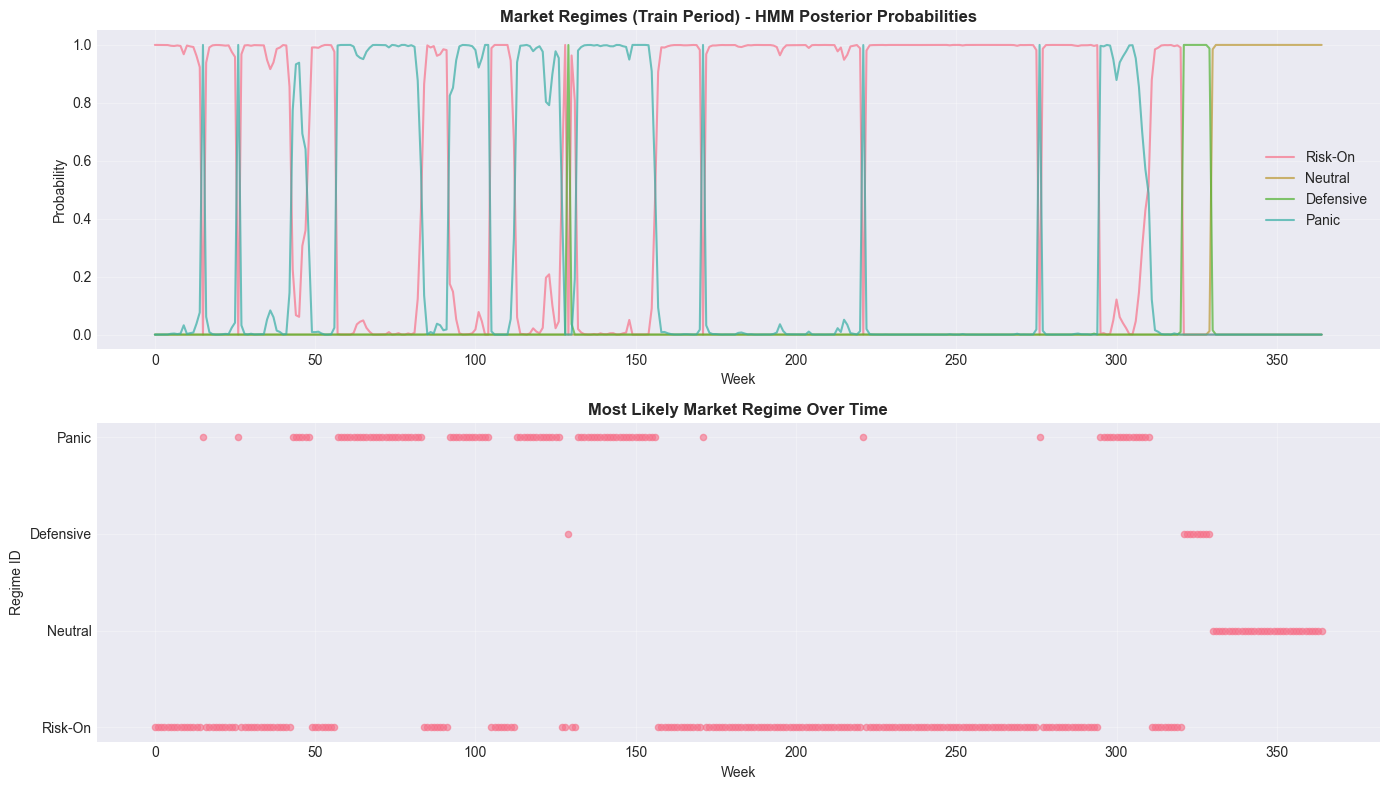


Regime Statistics (Train Period):

Risk-On:
  spy_ret_1d: 0.0001
  spy_ret_5d: 0.0015
  spy_ret_20d: 0.0056
  spy_vol_5d: 0.0072
  spy_vol_20d: 0.0075

Neutral:
  spy_ret_1d: 0.0013
  spy_ret_5d: 0.0068
  spy_ret_20d: 0.0350
  spy_vol_5d: 0.0110
  spy_vol_20d: 0.0125

Defensive:
  spy_ret_1d: -0.0009
  spy_ret_5d: -0.0189
  spy_ret_20d: -0.0780
  spy_vol_5d: 0.0378
  spy_vol_20d: 0.0376

Panic:
  spy_ret_1d: 0.0005
  spy_ret_5d: 0.0042
  spy_ret_20d: 0.0158
  spy_vol_5d: 0.0061
  spy_vol_20d: 0.0072


In [3]:
# Split into Train/Validation/Test (2014-2020 / 2021-2022 / 2023-2026)
split_date_train = '2020-12-31'
split_date_val = '2022-12-31'

train_mask = all_features.index <= split_date_train
val_mask = (all_features.index > split_date_train) & (all_features.index <= split_date_val)
test_mask = all_features.index > split_date_val

train_features = all_features[train_mask].reset_index(drop=True)
train_returns = asset_targets[train_mask]

val_features = all_features[val_mask].reset_index(drop=True)
val_returns = asset_targets[val_mask]

test_features = all_features[test_mask].reset_index(drop=True)
test_returns = asset_targets[test_mask]

# Select only numeric columns and drop NaN
numeric_cols = train_features.select_dtypes(include=[np.number]).columns
train_features = train_features[numeric_cols].fillna(0)
val_features = val_features[numeric_cols].fillna(0)
test_features = test_features[numeric_cols].fillna(0)

print(f"Train data: {len(train_features)} weeks")
print(f"Val data: {len(val_features)} weeks")
print(f"Test data: {len(test_features)} weeks")
print(f"Train features shape: {train_features.shape} (numeric features only)")

# Fit HMM on training data
print("\n=== Fit Gaussian HMM ===")
hmm = GaussianHMMRegimeDetector(n_regimes=4, pca_components=10, random_state=42)
hmm.fit(train_features, regime_names=["Risk-On", "Neutral", "Defensive", "Panic"])

print(f"HMM fitted with {hmm.n_regimes} regimes")
print(f"Regime names: {hmm.get_regime_names()}")

# Predict regimes for all periods
train_regime_posteriors = hmm.predict_proba(train_features)
val_regime_posteriors = hmm.predict_proba(val_features)
test_regime_posteriors = hmm.predict_proba(test_features)

print(f"\nRegime posteriors shape:")
print(f"  Train: {train_regime_posteriors.shape}")
print(f"  Val: {val_regime_posteriors.shape}")
print(f"  Test: {test_regime_posteriors.shape}")

# Visualize regime detection
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot regime probabilities over time
for regime_id in range(hmm.n_regimes):
    axes[0].plot(range(len(train_regime_posteriors)), train_regime_posteriors[:, regime_id], 
                 label=hmm.regime_names[regime_id], alpha=0.7)
axes[0].set_title('Market Regimes (Train Period) - HMM Posterior Probabilities', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Week')
axes[0].set_ylabel('Probability')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot predicted regime labels
predicted_regimes = hmm.predict_regimes(train_features)
axes[1].scatter(range(len(predicted_regimes)), predicted_regimes, alpha=0.6, s=20)
axes[1].set_title('Most Likely Market Regime Over Time', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Week')
axes[1].set_ylabel('Regime ID')
axes[1].set_yticks(range(hmm.n_regimes))
axes[1].set_yticklabels(hmm.regime_names)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nRegime Statistics (Train Period):")
regime_stats = hmm.get_regime_stats()
for regime_id, stats in regime_stats.items():
    print(f"\n{hmm.regime_names[regime_id]}:")
    for feature, value in list(stats.items())[:5]:
        print(f"  {feature}: {value:.4f}")

## 4. Create Training, Validation, and Test Environments

In [4]:
# Asset returns for portfolio: [SPY, TLT, GLD, Cash(~0)]
# Check available columns and use those
print(f"Available columns in asset_targets: {asset_targets.columns.tolist()}")

# Use columns that match the expected assets
spy_col = 'SPY_return' if 'SPY_return' in asset_targets.columns else next((c for c in asset_targets.columns if 'SPY' in c.upper()), None)
tlt_col = 'TLT_return' if 'TLT_return' in asset_targets.columns else next((c for c in asset_targets.columns if 'TLT' in c.upper()), None)
gld_col = 'GLD_return' if 'GLD_return' in asset_targets.columns else next((c for c in asset_targets.columns if 'GLD' in c.upper()), None)

print(f"Using columns: SPY={spy_col}, TLT={tlt_col}, GLD={gld_col}")

spy_returns = asset_targets[spy_col] if spy_col else np.random.randn(len(asset_targets)) * 0.02
tlt_returns = asset_targets[tlt_col] if tlt_col else np.random.randn(len(asset_targets)) * 0.01
gld_returns = asset_targets[gld_col] if gld_col else np.random.randn(len(asset_targets)) * 0.015
cash_returns = np.zeros_like(spy_returns)  # Cash has ~0 return

portfolio_returns = pd.DataFrame({
    'SPY': spy_returns.values if hasattr(spy_returns, 'values') else spy_returns,
    'TLT': tlt_returns.values if hasattr(tlt_returns, 'values') else tlt_returns,
    'GLD': gld_returns.values if hasattr(gld_returns, 'values') else gld_returns,
    'Cash': cash_returns,
})

# Normalize features (important for neural network)
scaler = StandardScaler()
train_market_scaled = scaler.fit_transform(train_features)
val_market_scaled = scaler.transform(val_features)
test_market_scaled = scaler.transform(test_features)

train_features_normalized = train_features.copy()
train_features_normalized[:] = train_market_scaled

val_features_normalized = val_features.copy()
val_features_normalized[:] = val_market_scaled

test_features_normalized = test_features.copy()
test_features_normalized[:] = test_market_scaled

# Create environments
train_env = WeeklyPortfolioEnv(
    features=train_features_normalized,
    regime_posteriors=train_regime_posteriors,
    asset_returns=portfolio_returns.iloc[:len(train_features_normalized)],
    transaction_cost=0.001,
    volatility_penalty=0.05,
    lookback_vol=4,
    seq_len=4
)

val_env = WeeklyPortfolioEnv(
    features=val_features_normalized,
    regime_posteriors=val_regime_posteriors,
    asset_returns=portfolio_returns.iloc[len(train_features_normalized):len(train_features_normalized)+len(val_features_normalized)],
    transaction_cost=0.001,
    volatility_penalty=0.05,
    lookback_vol=4,
    seq_len=4
)

test_env = WeeklyPortfolioEnv(
    features=test_features_normalized,
    regime_posteriors=test_regime_posteriors,
    asset_returns=portfolio_returns.iloc[len(train_features_normalized)+len(val_features_normalized):],
    transaction_cost=0.001,
    volatility_penalty=0.05,
    lookback_vol=4,
    seq_len=4
)

print(f"Environment Configuration:")
print(f"  State dimension: {train_env.observation_space.shape}")
print(f"  Action dimension: {train_env.action_space.n}")
print(f"  Sequence length: {train_env.seq_len}")
print(f"  Portfolio templates: {len(train_env.PORTFOLIO_TEMPLATES)}")
print(f"\nPortfolio Actions:")
for action_id, name in enumerate(train_env.ACTION_NAMES):
    print(f"  {action_id}: {name}")

Available columns in asset_targets: ['spy_weekly_close', 'tlt_weekly_close', 'gld_weekly_close', 'week_last_trade_date', 'next_return_spy', 'next_return_tlt', 'next_return_gld', 'source']
Using columns: SPY=spy_weekly_close, TLT=tlt_weekly_close, GLD=gld_weekly_close
Environment Configuration:
  State dimension: (4, 62)
  Action dimension: 7
  Sequence length: 4
  Portfolio templates: 7

Portfolio Actions:
  0: 100% Cash
  1: 100% SPY
  2: 100% TLT
  3: 100% GLD
  4: 80% SPY / 20% TLT
  5: 60% SPY / 30% TLT / 10% GLD
  6: 50% TLT / 50% GLD


## 5. Initialize Attention DQN Agent

In [5]:
# Initialize DQN agent using FinRL (stable-baselines3)
agent = DQN(
    'MlpPolicy',
    train_env,
    learning_rate=1e-4,
    buffer_size=10000,
    learning_starts=1000,
    batch_size=32,
    tau=1.0,
    gamma=0.99,
    train_freq=1,
    target_update_interval=1000,
    exploration_fraction=0.15,
    exploration_initial_eps=1.0,
    exploration_final_eps=0.05,
    device=device,
    verbose=1
)

print("=== FinRL DQN Agent Initialized ===")
print(f"Device: {agent.device}")
print(f"Policy: MlpPolicy")
print(f"State space: {train_env.observation_space}")
print(f"Action space: {train_env.action_space}")
print(f"Learning rate: {agent.learning_rate}")
print(f"Gamma: {agent.gamma}")
print(f"\nBuffer size: {agent.buffer_size}")
print(f"Batch size: {agent.batch_size}")
print(f"Target update interval: {agent.target_update_interval}")

# Test forward pass (gymnasium returns (obs, info) tuple)
obs, info = train_env.reset()
print(f"\nObservation shape: {obs.shape}")
print(f"Info keys: {info.keys() if isinstance(info, dict) else 'N/A'}")

Using mps device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
=== FinRL DQN Agent Initialized ===
Device: mps
Policy: MlpPolicy
State space: Box(-inf, inf, (4, 62), float32)
Action space: Discrete(7)
Learning rate: 0.0001
Gamma: 0.99

Buffer size: 10000
Batch size: 32
Target update interval: 1000

Observation shape: (4, 62)
Info keys: dict_keys([])


## 6. Train Attention-Enhanced DQN Agent

In [6]:
# Train the FinRL DQN agent
print("=== Starting DQN Training with FinRL ===\n")

import importlib
import ml.training_utils as training_utils_mod
training_utils_mod = importlib.reload(training_utils_mod)

training_results = training_utils_mod.train_dqn_finrl(
    train_env=train_env,
    val_env=val_env,
    total_timesteps=100000,
    eval_freq=2000,
    early_stopping_patience=10,
    learning_rate=1e-4,
    exploration_fraction=0.15,
    exploration_final_eps=0.05,
    target_update_interval=1000,
    buffer_size=10000,
    batch_size=32,
    device=device
)

agent = training_results['agent']
val_history = training_results['val_history']

print(f"\nTraining completed!")
print(f"Total timesteps: {training_results['total_timesteps']}")
print(f"Best validation reward: {training_results['best_val_reward']:.4f}")
print(f"Validation history length: {len(val_history)}")

Output()

=== Starting DQN Training with FinRL ===

Using mps device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
=== Training DQN Agent with FinRL ===
Device: mps
Total timesteps: 100000
Evaluation frequency: 2000
Early stopping patience: 10



----------------------------------
| rollout/            |          |
|    ep_len_mean      | 357      |
|    ep_rew_mean      | 4.84e+04 |
|    exploration_rate | 0.91     |
| time/               |          |
|    episodes         | 4        |
|    fps              | 417      |
|    time_elapsed     | 3        |
|    total_timesteps  | 1428     |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 116      |
|    n_updates        | 427      |
----------------------------------


Validation at step 2000: reward=32908.7664

-> New best validation reward!

...

Validation at step 22000: reward=38413.4994

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 357      |
|    ep_rew_mean      | 6.7e+04  |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 64       |
|    fps              | 213      |
|    time_elapsed     | 106      |
|    total_timesteps  | 22848    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 4.08     |
|    n_updates        | 21847    |
----------------------------------


Validation at step 24000: reward=38413.4994

Early stopping triggered at step 24000


Training completed!
Total timesteps: 24000
Best validation reward: 38413.4994
Validation history length: 12


## 6.1 Train Actor-Critic (A2C) + Action Probability Dynamics

In [7]:
# Train an Actor-Critic policy (A2C) and visualize action probabilities over time
print("=== Training Actor-Critic (A2C) ===")

import plotly.express as px

# A2C is a policy-gradient actor-critic model with explicit action probabilities.
ac_agent = A2C(
    'MlpPolicy',
    train_env,
    learning_rate=7e-4,
    gamma=0.99,
    n_steps=64,
    ent_coef=0.01,
    vf_coef=0.5,
    device=device,
    verbose=1
)

ac_total_timesteps = 30000
ac_agent.learn(total_timesteps=ac_total_timesteps, progress_bar=True)
print(f"A2C training complete. Timesteps: {ac_total_timesteps}")

# Evaluate deterministic actor-critic policy on test period
ac_test_eval = evaluate_episode(ac_agent, test_env, deterministic=True)
print("\nActor-Critic Test Performance:")
print(f"  Total Reward: {ac_test_eval['reward']:.4f}")
print(f"  Cumulative Return: {ac_test_eval.get('cumulative_return', 0):.4f}")
print(f"  Sharpe Ratio: {ac_test_eval.get('sharpe_ratio', 0):.4f}")
print(f"  Max Drawdown: {ac_test_eval.get('max_drawdown', 0):.4f}")

# Roll forward and record per-step action probability vector
obs, _ = test_env.reset()
prob_rows = []
max_steps_prob = min(200, len(test_env.features))
action_names_local = list(train_env.ACTION_NAMES)

for t in range(max_steps_prob):
    obs_tensor = torch.tensor(obs, dtype=torch.float32, device=ac_agent.device).unsqueeze(0)
    with torch.no_grad():
        dist = ac_agent.policy.get_distribution(obs_tensor)
        probs = dist.distribution.probs.squeeze(0).detach().cpu().numpy()

    action, _ = ac_agent.predict(obs, deterministic=True)
    action_id = int(action.item() if isinstance(action, np.ndarray) else action)

    row = {'step': t, 'chosen_action': action_names_local[action_id]}
    for i, name in enumerate(action_names_local):
        row[name] = float(probs[i])
    prob_rows.append(row)

    obs, reward, terminated, truncated, _ = test_env.step(action_id)
    if terminated or truncated:
        break

prob_df = pd.DataFrame(prob_rows)
prob_long = prob_df.melt(
    id_vars=['step', 'chosen_action'],
    value_vars=action_names_local,
    var_name='action_name',
    value_name='probability',
)

fig_probs = px.line(
    prob_long,
    x='step',
    y='probability',
    color='action_name',
    title='Actor-Critic: Action Probabilities Over Time',
    labels={'probability': 'Action probability', 'step': 'Test step', 'action_name': 'Action'},
)
fig_probs.update_layout(height=520, width=1200, legend=dict(orientation='h', y=1.02, x=0))
fig_probs.show()

fig_chosen = px.scatter(
    prob_df,
    x='step',
    y='chosen_action',
    title='Actor-Critic: Chosen Action Timeline',
    labels={'step': 'Test step', 'chosen_action': 'Chosen action'},
)
fig_chosen.update_layout(height=360, width=1200)
fig_chosen.show()

print("Action probability diagnostics ready.")

=== Training Actor-Critic (A2C) ===


Output()

Using mps device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


-------------------------------------
| rollout/              |           |
|    ep_len_mean        | 357       |
|    ep_rew_mean        | 4.56e+04  |
| time/                 |           |
|    fps                | 289       |
|    iterations         | 100       |
|    time_elapsed       | 22        |
|    total_timesteps    | 6400      |
| train/                |           |
|    entropy_loss       | -1.89     |
|    explained_variance | -5.01e-06 |
|    learning_rate      | 0.0007    |
|    n_updates          | 99        |
|    policy_loss        | 6.11e+03  |
|    value_loss         | 1.33e+07  |
-------------------------------------


------------------------------------
| rollout/              |          |
|    ep_len_mean        | 357      |
|    ep_rew_mean        | 4.64e+04 |
| time/                 |          |
|    fps                | 291      |
|    iterations         | 200      |
|    time_elapsed       | 43       |
|    total_timesteps    | 12800    |
| train/                |          |
|    entropy_loss       | -1.93    |
|    explained_variance | 2.92e-06 |
|    learning_rate      | 0.0007   |
|    n_updates          | 199      |
|    policy_loss        | 6.88e+03 |
|    value_loss         | 1.51e+07 |
------------------------------------


------------------------------------
| rollout/              |          |
|    ep_len_mean        | 357      |
|    ep_rew_mean        | 4.68e+04 |
| time/                 |          |
|    fps                | 293      |
|    iterations         | 300      |
|    time_elapsed       | 65       |
|    total_timesteps    | 19200    |
| train/                |          |
|    entropy_loss       | -1.91    |
|    explained_variance | 8.34e-07 |
|    learning_rate      | 0.0007   |
|    n_updates          | 299      |
|    policy_loss        | 6.49e+03 |
|    value_loss         | 1.37e+07 |
------------------------------------


-------------------------------------
| rollout/              |           |
|    ep_len_mean        | 357       |
|    ep_rew_mean        | 4.7e+04   |
| time/                 |           |
|    fps                | 293       |
|    iterations         | 400       |
|    time_elapsed       | 87        |
|    total_timesteps    | 25600     |
| train/                |           |
|    entropy_loss       | -1.92     |
|    explained_variance | -5.96e-07 |
|    learning_rate      | 0.0007    |
|    n_updates          | 399       |
|    policy_loss        | 6.33e+03  |
|    value_loss         | 1.32e+07  |
-------------------------------------


A2C training complete. Timesteps: 30000

Actor-Critic Test Performance:
  Total Reward: 63225.2545
  Cumulative Return: inf
  Sharpe Ratio: 13.7912
  Max Drawdown: nan


Action probability diagnostics ready.


## 6.2 Train PPO + Action Probability Dynamics

In [8]:
# Train PPO and visualize action probabilities over time (fast-mode friendly)
print("=== Training PPO ===")

import plotly.express as px

FAST_MODE = globals().get('FAST_MODE', True)
ppo_train_steps = 6000 if FAST_MODE else 30000
ppo_diag_steps = 80 if FAST_MODE else 200
print(f"FAST_MODE={FAST_MODE} | train_steps={ppo_train_steps} | diag_steps={ppo_diag_steps}")

ppo_agent = PPO(
    'MlpPolicy',
    train_env,
    learning_rate=3e-4,
    n_steps=256 if FAST_MODE else 512,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    vf_coef=0.5,
    device=device,
    verbose=1
)

ppo_total_timesteps = ppo_train_steps
ppo_agent.learn(total_timesteps=ppo_total_timesteps, progress_bar=not FAST_MODE)
print(f"PPO training complete. Timesteps: {ppo_total_timesteps}")

ppo_test_eval = evaluate_episode(ppo_agent, test_env, deterministic=True)
print("\nPPO Test Performance:")
print(f"  Total Reward: {ppo_test_eval['reward']:.4f}")
print(f"  Cumulative Return: {ppo_test_eval.get('cumulative_return', 0):.4f}")
print(f"  Sharpe Ratio: {ppo_test_eval.get('sharpe_ratio', 0):.4f}")
print(f"  Max Drawdown: {ppo_test_eval.get('max_drawdown', 0):.4f}")

obs, _ = test_env.reset()
ppo_prob_rows = []
max_steps_prob = min(ppo_diag_steps, len(test_env.features))
action_names_local = list(train_env.ACTION_NAMES)

for t in range(max_steps_prob):
    obs_tensor = torch.tensor(obs, dtype=torch.float32, device=ppo_agent.device).unsqueeze(0)
    with torch.no_grad():
        ppo_dist = ppo_agent.policy.get_distribution(obs_tensor)
        ppo_probs = ppo_dist.distribution.probs.squeeze(0).detach().cpu().numpy()

    action, _ = ppo_agent.predict(obs, deterministic=True)
    action_id = int(action.item() if isinstance(action, np.ndarray) else action)

    row = {'step': t, 'chosen_action': action_names_local[action_id]}
    for i, name in enumerate(action_names_local):
        row[name] = float(ppo_probs[i])
    ppo_prob_rows.append(row)

    obs, reward, terminated, truncated, _ = test_env.step(action_id)
    if terminated or truncated:
        break

ppo_prob_df = pd.DataFrame(ppo_prob_rows)
ppo_prob_long = ppo_prob_df.melt(
    id_vars=['step', 'chosen_action'],
    value_vars=action_names_local,
    var_name='action_name',
    value_name='probability',
)

fig_ppo_probs = px.line(
    ppo_prob_long,
    x='step',
    y='probability',
    color='action_name',
    title='PPO: Action Probabilities Over Time',
    labels={'probability': 'Action probability', 'step': 'Test step', 'action_name': 'Action'},
)
fig_ppo_probs.update_layout(height=520, width=1200, legend=dict(orientation='h', y=1.02, x=0))
fig_ppo_probs.show()

fig_ppo_chosen = px.scatter(
    ppo_prob_df,
    x='step',
    y='chosen_action',
    title='PPO: Chosen Action Timeline',
    labels={'step': 'Test step', 'chosen_action': 'Chosen action'},
)
fig_ppo_chosen.update_layout(height=360, width=1200)
fig_ppo_chosen.show()

print("PPO action probability diagnostics ready.")

=== Training PPO ===
FAST_MODE=True | train_steps=6000 | diag_steps=80
Using mps device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------
| time/              |     |
|    fps             | 314 |
|    iterations      | 1   |
|    time_elapsed    | 0   |
|    total_timesteps | 256 |
----------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 357          |
|    ep_rew_mean          | 4.66e+04     |
| time/                   |              |
|    fps                  | 271          |
|    iterations           | 2            |
|    time_elapsed         | 1            |
|    total_timesteps      | 512          |
| train/                  |              |
|    approx_kl            | 7.962319e-05 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.95        |
|    explained_variance   | -9

PPO action probability diagnostics ready.


## 6.3 Train PPO with Native Temporal Attention Policy

> This section makes PPO use an internal attention feature extractor (native attention in the policy network), not only post-hoc explainability.

In [9]:
# Native-attention PPO: custom temporal attention feature extractor for policy/value networks
print("=== Training PPO with Native Temporal Attention ===")

import torch.nn as nn
from gymnasium import spaces
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
import plotly.express as px

FAST_MODE = globals().get('FAST_MODE', True)
ppo_attn_train_steps = 8000 if FAST_MODE else 30000
ppo_attn_diag_steps = 80 if FAST_MODE else 200
print(f"FAST_MODE={FAST_MODE} | train_steps={ppo_attn_train_steps} | diag_steps={ppo_attn_diag_steps}")

class TemporalAttentionExtractor(BaseFeaturesExtractor):
    """Apply self-attention over the temporal axis of [T, F] observations."""
    def __init__(self, observation_space: spaces.Box, features_dim: int = 128):
        super().__init__(observation_space, features_dim)
        if len(observation_space.shape) != 2:
            raise ValueError(
                f"Expected observation shape [T, F], got {observation_space.shape}. "
                "Set env to return sequence windows before using this extractor."
            )

        feat_dim = observation_space.shape[1]
        d_model = 64
        n_heads = 4

        self.input_proj = nn.Linear(feat_dim, d_model)
        self.self_attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.norm = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, features_dim),
            nn.ReLU(),
        )

        self.latest_attn_weights = None

    def forward(self, observations: torch.Tensor) -> torch.Tensor:
        x = self.input_proj(observations)
        attn_out, attn_weights = self.self_attn(x, x, x, need_weights=True, average_attn_weights=False)
        x = self.norm(x + attn_out)
        pooled = x.mean(dim=1)
        self.latest_attn_weights = attn_weights.detach()
        return self.mlp(pooled)

def collect_policy_probabilities(policy_agent, env, action_names, max_steps=200):
    obs, _ = env.reset()
    rows = []
    max_steps = min(max_steps, len(env.features))

    for t in range(max_steps):
        obs_tensor = torch.tensor(obs, dtype=torch.float32, device=policy_agent.device).unsqueeze(0)
        with torch.no_grad():
            dist = policy_agent.policy.get_distribution(obs_tensor)
            probs = dist.distribution.probs.squeeze(0).detach().cpu().numpy()

        action, _ = policy_agent.predict(obs, deterministic=True)
        action_id = int(action.item() if isinstance(action, np.ndarray) else action)

        row = {'step': t, 'chosen_action': action_names[action_id]}
        for i, name in enumerate(action_names):
            row[name] = float(probs[i])
        rows.append(row)

        obs, _, terminated, truncated, _ = env.step(action_id)
        if terminated or truncated:
            break

    prob_df = pd.DataFrame(rows)
    prob_long = prob_df.melt(
        id_vars=['step', 'chosen_action'],
        value_vars=action_names,
        var_name='action_name',
        value_name='probability',
    )
    return prob_df, prob_long

def plot_action_diagnostics(prob_df, prob_long, title_prefix):
    fig_probs = px.line(
        prob_long,
        x='step',
        y='probability',
        color='action_name',
        title=f'{title_prefix}: Action Probabilities Over Time',
        labels={'probability': 'Action probability', 'step': 'Test step', 'action_name': 'Action'},
    )
    fig_probs.update_layout(height=520, width=1200, legend=dict(orientation='h', y=1.02, x=0))
    fig_probs.show()

    fig_chosen = px.scatter(
        prob_df,
        x='step',
        y='chosen_action',
        title=f'{title_prefix}: Chosen Action Timeline',
        labels={'step': 'Test step', 'chosen_action': 'Chosen action'},
    )
    fig_chosen.update_layout(height=360, width=1200)
    fig_chosen.show()

policy_kwargs_attn = dict(
    features_extractor_class=TemporalAttentionExtractor,
    features_extractor_kwargs=dict(features_dim=128),
    net_arch=dict(pi=[128, 64], vf=[128, 64]),
)

ppo_attn_agent = PPO(
    'MlpPolicy',
    train_env,
    learning_rate=3e-4,
    n_steps=256 if FAST_MODE else 512,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    vf_coef=0.5,
    policy_kwargs=policy_kwargs_attn,
    device=device,
    verbose=1,
)

ppo_attn_total_timesteps = ppo_attn_train_steps
ppo_attn_agent.learn(total_timesteps=ppo_attn_total_timesteps, progress_bar=not FAST_MODE)
print(f"Native-attention PPO training complete. Timesteps: {ppo_attn_total_timesteps}")

ppo_attn_test_eval = evaluate_episode(ppo_attn_agent, test_env, deterministic=True)
print("\nNative-Attention PPO Test Performance:")
print(f"  Total Reward: {ppo_attn_test_eval['reward']:.4f}")
print(f"  Cumulative Return: {ppo_attn_test_eval.get('cumulative_return', 0):.4f}")
print(f"  Sharpe Ratio: {ppo_attn_test_eval.get('sharpe_ratio', 0):.4f}")
print(f"  Max Drawdown: {ppo_attn_test_eval.get('max_drawdown', 0):.4f}")

action_names_local = list(train_env.ACTION_NAMES)
attn_prob_df, attn_prob_long = collect_policy_probabilities(
    policy_agent=ppo_attn_agent,
    env=test_env,
    action_names=action_names_local,
    max_steps=ppo_attn_diag_steps,
    )
plot_action_diagnostics(attn_prob_df, attn_prob_long, 'Native-Attention PPO')

obs, _ = test_env.reset()
obs_batch = torch.tensor(obs, dtype=torch.float32, device=ppo_attn_agent.device).unsqueeze(0)
_ = ppo_attn_agent.policy.extract_features(obs_batch)
extractor = ppo_attn_agent.policy.features_extractor
native_attn = getattr(extractor, 'latest_attn_weights', None)

if native_attn is not None:
    native_attn_mean = native_attn.mean(dim=(0, 1)).detach().cpu().numpy()
    token_labels = [f"t-{train_env.seq_len-1-i}" for i in range(train_env.seq_len)]
    fig_native_attn = px.imshow(
        native_attn_mean,
        x=token_labels,
        y=token_labels,
        color_continuous_scale='Teal',
        title='Native PPO Attention Matrix (mean over heads)',
        labels={'x': 'Key timestep', 'y': 'Query timestep', 'color': 'weight'},
    )
    fig_native_attn.update_layout(width=760, height=620)
    fig_native_attn.show()
else:
    print("Native attention weights not available yet. Run one predict/eval step and try again.")

print("Native-attention PPO diagnostics ready.")

=== Training PPO with Native Temporal Attention ===
FAST_MODE=True | train_steps=8000 | diag_steps=80
Using mps device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------
| time/              |     |
|    fps             | 203 |
|    iterations      | 1   |
|    time_elapsed    | 1   |
|    total_timesteps | 256 |
----------------------------
-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 357           |
|    ep_rew_mean          | 4.78e+04      |
| time/                   |               |
|    fps                  | 183           |
|    iterations           | 2             |
|    time_elapsed         | 2             |
|    total_timesteps      | 512           |
| train/                  |               |
|    approx_kl            | 0.00013180054 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -

Native-attention PPO diagnostics ready.


## 6.4 Model Comparison: DQN vs PPO-MLP vs PPO-Native-Attention

This section compares test performance and action diversity across the three main agents.

Metrics: total reward, cumulative return, Sharpe ratio, max drawdown, and action entropy (diversity).

In [10]:
# Compare DQN, PPO (MLP), and PPO (Native Attention) in one panel
print("=== Model Comparison: DQN vs PPO-MLP vs PPO-Native-Attention ===")

import plotly.express as px
import plotly.graph_objects as go

def _safe_metric(eval_dict, key):
    return float(eval_dict.get(key, np.nan)) if isinstance(eval_dict, dict) else np.nan

def _action_entropy_from_series(action_series):
    if action_series is None or len(action_series) == 0:
        return np.nan
    probs = action_series.value_counts(normalize=True).values
    return float(-(probs * np.log(probs + 1e-12)).sum())

def _build_model_row(model_name, eval_dict=None, action_df=None, action_col=None):
    entropy = np.nan
    if isinstance(action_df, pd.DataFrame) and action_col in action_df.columns:
        entropy = _action_entropy_from_series(action_df[action_col])
    elif isinstance(eval_dict, dict) and 'actions' in eval_dict:
        tmp_df = pd.DataFrame(eval_dict['actions'])
        if 'action_name' in tmp_df.columns:
            entropy = _action_entropy_from_series(tmp_df['action_name'])

    return {
        'model': model_name,
        'reward': _safe_metric(eval_dict, 'reward'),
        'cumulative_return': _safe_metric(eval_dict, 'cumulative_return'),
        'sharpe_ratio': _safe_metric(eval_dict, 'sharpe_ratio'),
        'max_drawdown': _safe_metric(eval_dict, 'max_drawdown'),
        'action_entropy': entropy,
    }

rows = [
    _build_model_row('DQN', globals().get('test_eval'), globals().get('actions_df'), 'action_name'),
    _build_model_row('PPO-MLP', globals().get('ppo_test_eval'), globals().get('ppo_prob_df'), 'chosen_action'),
    _build_model_row('PPO-Native-Attn', globals().get('ppo_attn_test_eval'), globals().get('attn_prob_df'), 'chosen_action'),
]

cmp_df = pd.DataFrame(rows)
print(cmp_df.round(4))

metric_cols = ['reward', 'cumulative_return', 'sharpe_ratio', 'max_drawdown', 'action_entropy']
if cmp_df[metric_cols].isna().all(axis=None):
    raise RuntimeError(
        "No model results found. Run: DQN eval (Section 8), PPO-MLP (Section 6.2), and/or PPO-Native-Attn (Section 6.3)."
    )

perf_long = cmp_df.melt(
    id_vars='model',
    value_vars=['reward', 'cumulative_return', 'sharpe_ratio', 'max_drawdown'],
    var_name='metric',
    value_name='value',
)

fig_perf = px.bar(
    perf_long,
    x='metric',
    y='value',
    color='model',
    barmode='group',
    title='Performance Comparison: DQN vs PPO Variants',
    labels={'metric': 'Metric', 'value': 'Value', 'model': 'Model'},
)
fig_perf.update_layout(height=520, width=1280, legend=dict(orientation='h', y=1.02, x=0))
fig_perf.show()

fig_entropy = px.bar(
    cmp_df,
    x='model',
    y='action_entropy',
    color='model',
    title='Action Diversity (Entropy) Comparison',
    labels={'action_entropy': 'Action entropy', 'model': 'Model'},
)
fig_entropy.update_layout(height=420, width=900, showlegend=False)
fig_entropy.show()

radar_metrics = ['reward', 'cumulative_return', 'sharpe_ratio', 'action_entropy']
radar_df = cmp_df[['model'] + radar_metrics].copy()

for metric in radar_metrics:
    col = radar_df[metric].astype(float)
    valid = col.dropna()
    if len(valid) == 0:
        radar_df[metric] = np.nan
    elif abs(valid.max() - valid.min()) < 1e-12:
        radar_df[metric] = 0.5
    else:
        radar_df[metric] = (col - valid.min()) / (valid.max() - valid.min())

fig_radar = go.Figure()
for _, row in radar_df.iterrows():
    vals = [row[m] for m in radar_metrics]
    fig_radar.add_trace(
        go.Scatterpolar(
            r=vals + [vals[0]],
            theta=radar_metrics + [radar_metrics[0]],
            fill='toself',
            name=row['model'],
        )
    )

fig_radar.update_layout(
    title='Normalized Multi-Metric Comparison (higher is better)',
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    height=560,
    width=900,
    legend=dict(orientation='h', y=1.05, x=0),
)
fig_radar.show()

print("Comparison complete.")
print("Tip: if PPO-Native-Attn row is NaN, run Section 6.3 first.")

=== Model Comparison: DQN vs PPO-MLP vs PPO-Native-Attention ===
             model      reward  cumulative_return  sharpe_ratio  max_drawdown  \
0              DQN         NaN                NaN           NaN           NaN   
1          PPO-MLP  68884.4961                inf       24.4663           NaN   
2  PPO-Native-Attn  71319.2182                inf       43.1532           NaN   

   action_entropy  
0             NaN  
1          0.4826  
2         -0.0000  


Comparison complete.
Tip: if PPO-Native-Attn row is NaN, run Section 6.3 first.


## 6.5 Hyperparameter Fine-Tune (PPO Native Attention)

Compact random/grid search over key PPO-native-attention hyperparameters using validation reward.
The best configuration is retrained and stored as `ppo_attn_hpo_best`.

In [11]:
# Hyperparameter fine-tune for PPO Native Attention (compact search)
print("=== Hyperparameter Fine-Tuning: PPO Native Attention ===")

import pandas as pd
import plotly.express as px

if 'TemporalAttentionExtractor' not in globals():
    raise RuntimeError("Run Section 6.3 first so TemporalAttentionExtractor is defined.")

FAST_MODE = globals().get('FAST_MODE', True)
print(f"FAST_MODE={FAST_MODE}")

selected_trials = [
    {'learning_rate': 1e-4, 'ent_coef': 0.005, 'n_steps': 256, 'clip_range': 0.2},
    {'learning_rate': 3e-4, 'ent_coef': 0.005, 'n_steps': 256, 'clip_range': 0.2},
    {'learning_rate': 7e-4, 'ent_coef': 0.0, 'n_steps': 256, 'clip_range': 0.15},
]
if not FAST_MODE:
    selected_trials += [
        {'learning_rate': 3e-4, 'ent_coef': 0.01, 'n_steps': 512, 'clip_range': 0.2},
        {'learning_rate': 7e-4, 'ent_coef': 0.005, 'n_steps': 512, 'clip_range': 0.15},
    ]

hpo_timesteps = 4000 if FAST_MODE else 12000
hpo_rows = []
best_score = -1e18
best_cfg = None
best_agent = None

for trial_idx, cfg in enumerate(selected_trials, start=1):
    print(f"\nTrial {trial_idx}/{len(selected_trials)}: {cfg}")

    policy_kwargs_hpo = dict(
        features_extractor_class=TemporalAttentionExtractor,
        features_extractor_kwargs=dict(features_dim=128),
        net_arch=dict(pi=[128, 64], vf=[128, 64]),
    )

    trial_agent = PPO(
        'MlpPolicy',
        train_env,
        learning_rate=cfg['learning_rate'],
        n_steps=cfg['n_steps'],
        batch_size=64,
        n_epochs=10,
        gamma=0.99,
        gae_lambda=0.95,
        clip_range=cfg['clip_range'],
        ent_coef=cfg['ent_coef'],
        vf_coef=0.5,
        policy_kwargs=policy_kwargs_hpo,
        device=device,
        verbose=0,
    )

    trial_agent.learn(total_timesteps=hpo_timesteps, progress_bar=False)

    val_eval = evaluate_episode(trial_agent, val_env, deterministic=True)
    val_reward = float(val_eval['reward'])
    print(f"Validation reward: {val_reward:.4f}")

    row = {
        **cfg,
        'trial': trial_idx,
        'val_reward': val_reward,
        'val_sharpe': float(val_eval.get('sharpe_ratio', 0.0)),
        'val_max_drawdown': float(val_eval.get('max_drawdown', 0.0)),
    }
    hpo_rows.append(row)

    if val_reward > best_score:
        best_score = val_reward
        best_cfg = cfg
        best_agent = trial_agent

ppo_attn_hpo_results = pd.DataFrame(hpo_rows).sort_values('val_reward', ascending=False)
print("\nTop configurations:")
print(ppo_attn_hpo_results.head())

if best_agent is None or best_cfg is None:
    raise RuntimeError("HPO failed to produce a valid best configuration.")

print(f"\nBest config: {best_cfg}")
print(f"Best validation reward: {best_score:.4f}")

ppo_attn_hpo_best = best_agent

test_eval_best = evaluate_episode(ppo_attn_hpo_best, test_env, deterministic=True)
print("\nBest HPO model test performance:")
for name in ['reward', 'cumulative_return', 'sharpe_ratio', 'max_drawdown']:
    value = float(test_eval_best.get(name, 0.0))
    print(f"  {name}: {value:.4f}")

fig_hpo = px.scatter(
    ppo_attn_hpo_results,
    x='trial',
    y='val_reward',
    color='learning_rate',
    symbol='n_steps',
    size='ent_coef',
    hover_data=['clip_range', 'val_sharpe', 'val_max_drawdown'],
    title='PPO Native-Attention HPO: Validation Reward by Trial',
    labels={'val_reward': 'Validation reward', 'trial': 'Trial #'},
)
fig_hpo.update_layout(height=500, width=1100)
fig_hpo.show()

print("HPO complete. Best model is stored in variable: ppo_attn_hpo_best")

=== Hyperparameter Fine-Tuning: PPO Native Attention ===
FAST_MODE=True

Trial 1/3: {'learning_rate': 0.0001, 'ent_coef': 0.005, 'n_steps': 256, 'clip_range': 0.2}
Validation reward: 33530.2226

Trial 2/3: {'learning_rate': 0.0003, 'ent_coef': 0.005, 'n_steps': 256, 'clip_range': 0.2}
Validation reward: 38413.4994

Trial 3/3: {'learning_rate': 0.0007, 'ent_coef': 0.0, 'n_steps': 256, 'clip_range': 0.15}
Validation reward: 27943.1881

Top configurations:
   learning_rate  ent_coef  n_steps  clip_range  trial    val_reward  \
1         0.0003     0.005      256        0.20      2  38413.499383   
0         0.0001     0.005      256        0.20      1  33530.222586   
2         0.0007     0.000      256        0.15      3  27943.188081   

   val_sharpe  val_max_drawdown  
1  107.200580               0.0  
0   80.744064               0.0  
2  105.878274               0.0  

Best config: {'learning_rate': 0.0003, 'ent_coef': 0.005, 'n_steps': 256, 'clip_range': 0.2}
Best validation reward:

HPO complete. Best model is stored in variable: ppo_attn_hpo_best


## 7. Visualize Training Progress

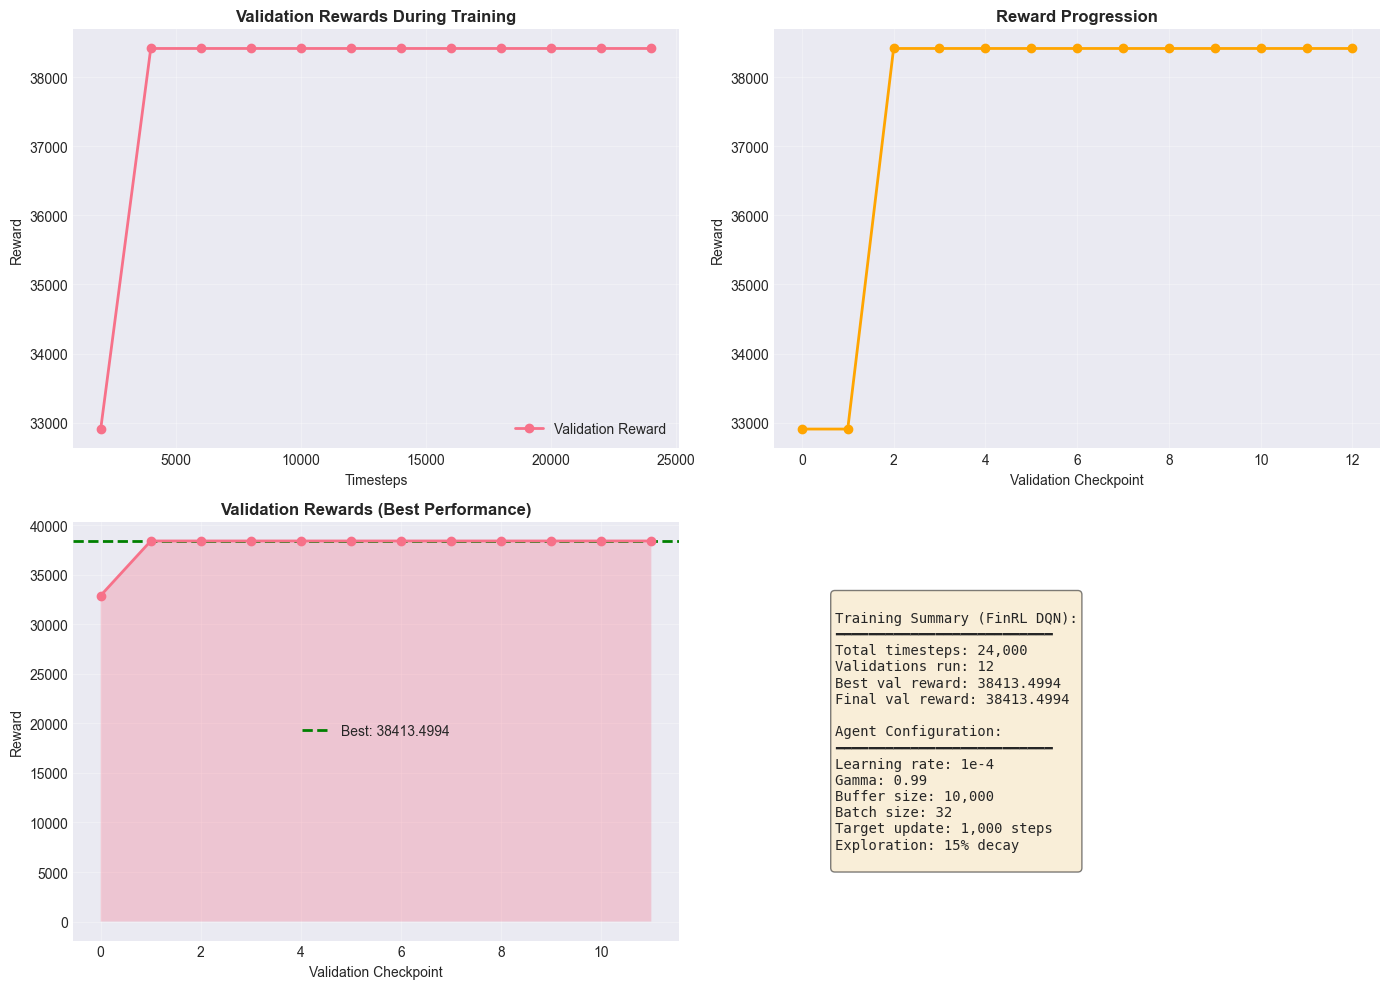

Training Statistics:
  Validation checkpoints: 12
  Best validation reward: 38413.4994
  Final validation reward: 38413.4994
  Reward improvement: 5504.7330


In [12]:
# Plot training progress with validation rewards
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Validation rewards over timesteps
if val_history:
    val_steps = [h['step'] for h in val_history]
    val_rewards = [h['reward'] for h in val_history]
    
    axes[0, 0].plot(val_steps, val_rewards, 'o-', linewidth=2, markersize=6, label='Validation Reward')
    axes[0, 0].set_title('Validation Rewards During Training', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Timesteps')
    axes[0, 0].set_ylabel('Reward')
    axes[0, 0].grid(alpha=0.3)
    axes[0, 0].legend()
    
    # Validation rewards improvement
    reward_improvement = [val_rewards[0]] + val_rewards
    axes[0, 1].plot(range(len(reward_improvement)), reward_improvement, 'o-', color='orange', linewidth=2, markersize=6)
    axes[0, 1].set_title('Reward Progression', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Validation Checkpoint')
    axes[0, 1].set_ylabel('Reward')
    axes[0, 1].grid(alpha=0.3)
    
    # Best validation reward marker
    best_idx = np.argmax(val_rewards)
    axes[1, 0].axhline(val_rewards[best_idx], color='green', linestyle='--', linewidth=2, label=f'Best: {val_rewards[best_idx]:.4f}')
    axes[1, 0].plot(range(len(val_rewards)), val_rewards, 'o-', linewidth=2, markersize=6)
    axes[1, 0].fill_between(range(len(val_rewards)), val_rewards, alpha=0.3)
    axes[1, 0].set_title('Validation Rewards (Best Performance)', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Validation Checkpoint')
    axes[1, 0].set_ylabel('Reward')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)

# Training info
axes[1, 1].axis('off')
info_text = f"""
Training Summary (FinRL DQN):
━━━━━━━━━━━━━━━━━━━━━━━━━━
Total timesteps: {training_results['total_timesteps']:,}
Validations run: {len(val_history)}
Best val reward: {training_results['best_val_reward']:.4f}
Final val reward: {val_rewards[-1]:.4f}

Agent Configuration:
━━━━━━━━━━━━━━━━━━━━━━━━━━
Learning rate: 1e-4
Gamma: 0.99
Buffer size: 10,000
Batch size: 32
Target update: 1,000 steps
Exploration: 15% decay
"""
axes[1, 1].text(0.1, 0.5, info_text, fontsize=10, verticalalignment='center', 
                family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("Training Statistics:")
print(f"  Validation checkpoints: {len(val_history)}")
print(f"  Best validation reward: {max(val_rewards):.4f}")
print(f"  Final validation reward: {val_rewards[-1]:.4f}")
print(f"  Reward improvement: {val_rewards[-1] - val_rewards[0]:.4f}")

## 8. Evaluate Agent on Test Period

=== Evaluating FinRL DQN on Test Period ===

Test Period Performance:
  Total Reward: 85677.4173
  Cumulative Return: inf
  Sharpe Ratio: 41.4287
  Max Drawdown: nan
  Episode Length: 160

Action Distribution:
action_name
100% SPY    160
Name: count, dtype: int64


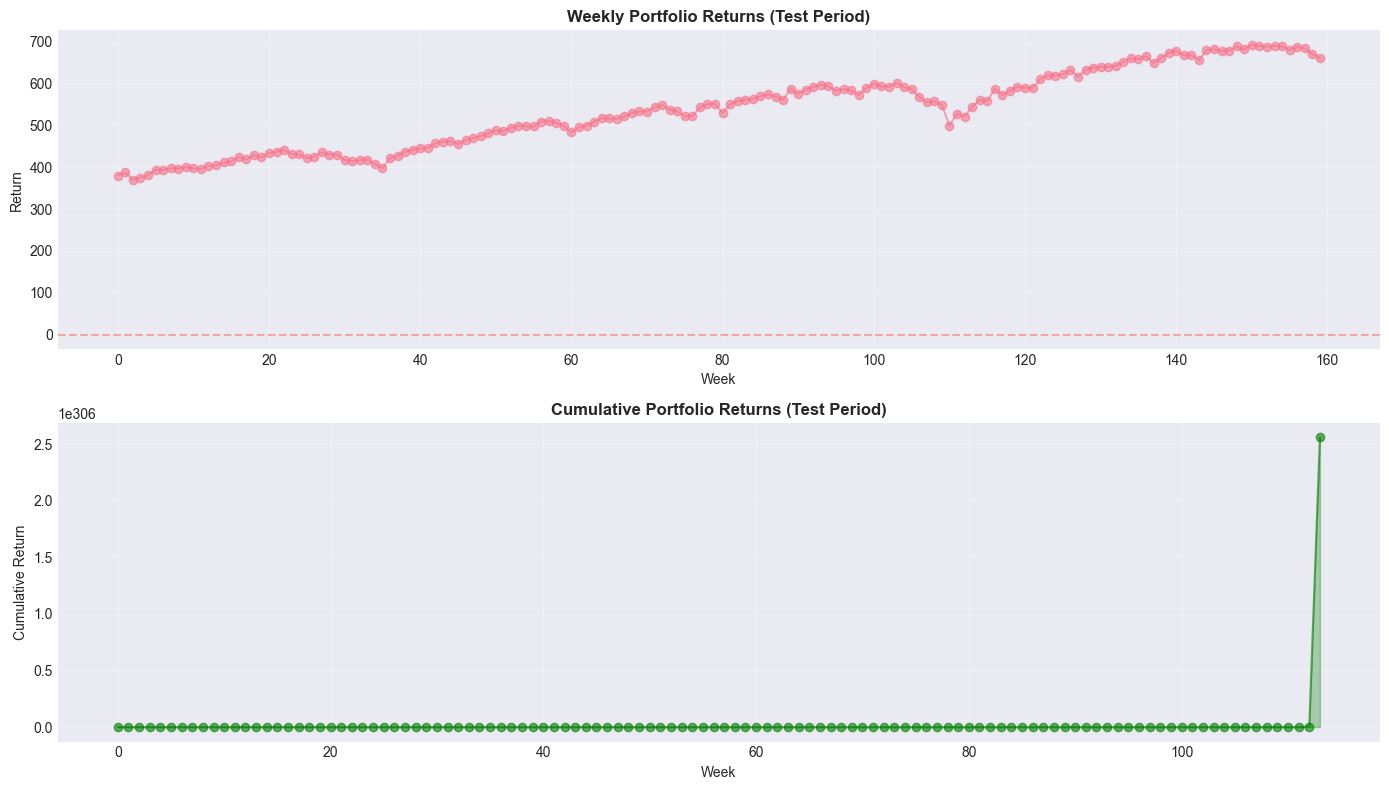

In [13]:
# Evaluate FinRL agent on test set
print("=== Evaluating FinRL DQN on Test Period ===\n")

test_eval = evaluate_episode(agent, test_env, deterministic=True)

print("Test Period Performance:")
print(f"  Total Reward: {test_eval['reward']:.4f}")
print(f"  Cumulative Return: {test_eval.get('cumulative_return', 0):.4f}")
print(f"  Sharpe Ratio: {test_eval.get('sharpe_ratio', 0):.4f}")
print(f"  Max Drawdown: {test_eval.get('max_drawdown', 0):.4f}")
print(f"  Episode Length: {test_eval['length']}")

# Extract action sequence
actions_df = pd.DataFrame(test_eval['actions'])
print(f"\nAction Distribution:")
print(actions_df['action_name'].value_counts())

# Weekly performance
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Returns over time
axes[0].plot(actions_df.index, actions_df['return'], marker='o', linestyle='-', alpha=0.6)
axes[0].axhline(0, color='r', linestyle='--', alpha=0.3)
axes[0].set_title('Weekly Portfolio Returns (Test Period)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Week')
axes[0].set_ylabel('Return')
axes[0].grid(alpha=0.3)

# Cumulative returns
cumulative_test_returns = np.cumprod(1 + actions_df['return']) - 1
axes[1].plot(cumulative_test_returns, marker='o', linestyle='-', alpha=0.6, color='green')
axes[1].fill_between(range(len(cumulative_test_returns)), cumulative_test_returns, alpha=0.3, color='green')
axes[1].set_title('Cumulative Portfolio Returns (Test Period)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Week')
axes[1].set_ylabel('Cumulative Return')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Analyze Attention Weights and Saliency

=== Attention Weights + Saliency ===

Epoch 10/30 - surrogate MSE: 15428077.866667
Epoch 20/30 - surrogate MSE: 671882.837500
Epoch 30/30 - surrogate MSE: 373868.531250


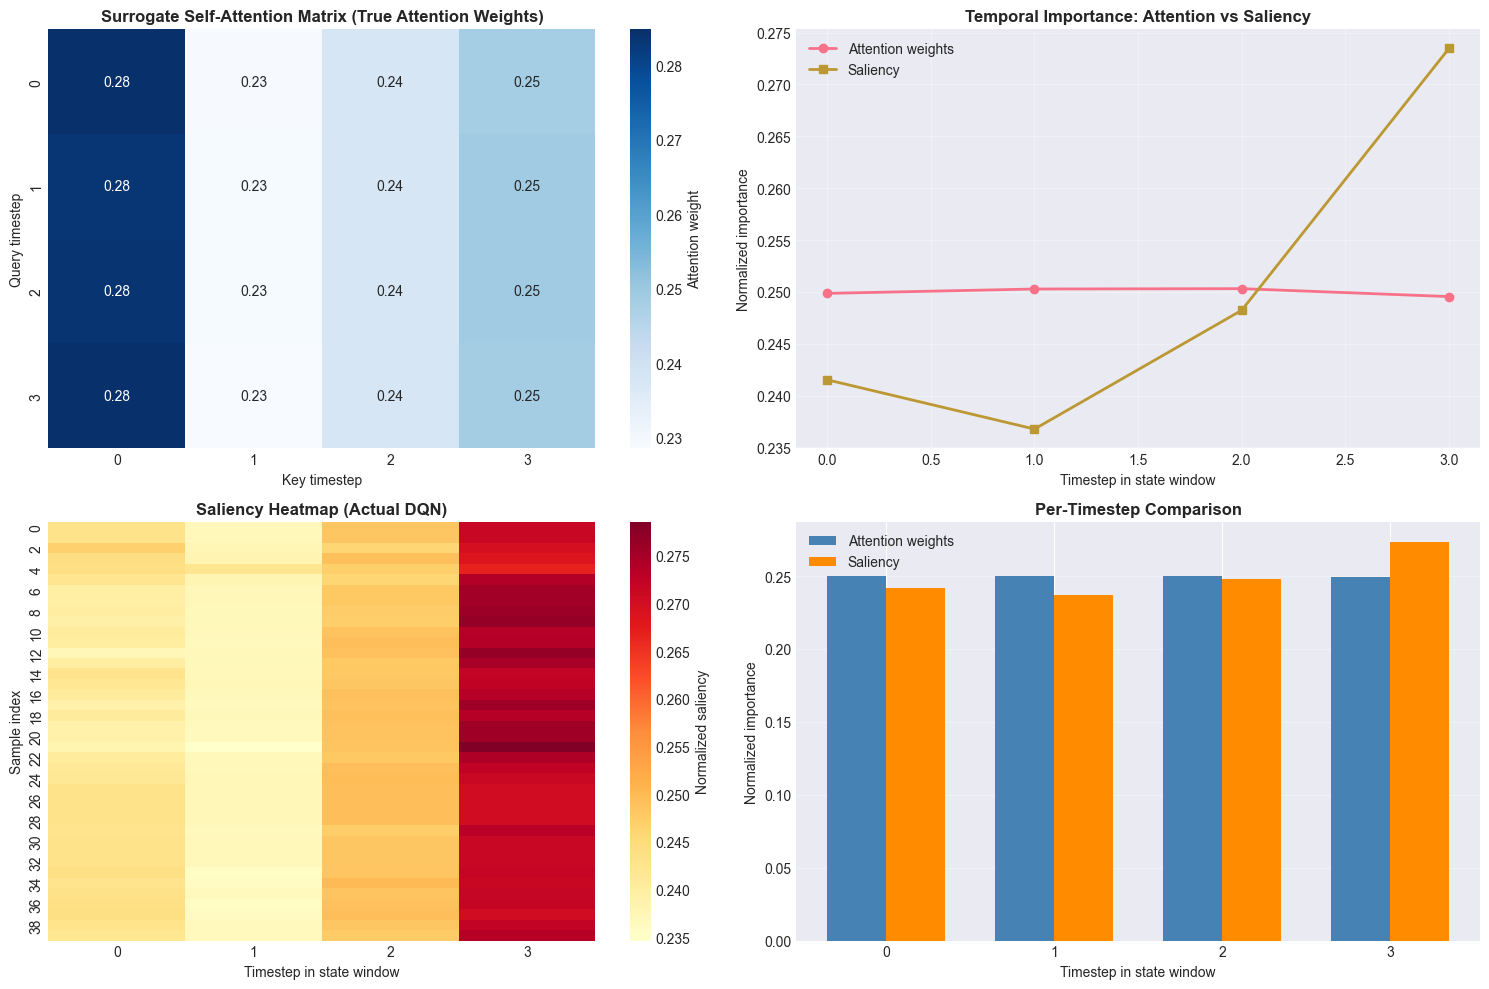

Interpretation:
- Top-left is TRUE attention weights from the surrogate attention model.
- Bottom-left and orange curves are gradient saliency from the actual DQN.
- If both agree on timesteps, attribution is more robust.
- If they diverge, policy sensitivity and learned temporal weighting differ.


In [14]:
# Plot BOTH: (1) attention weights (from an attention-based surrogate model)
# and (2) saliency (from gradients of the actual FinRL DQN).
print("=== Attention Weights + Saliency ===\n")

import torch
import torch.nn as nn
import torch.optim as optim

# -----------------------------
# 1) Build a dataset of states
# -----------------------------
seq_len = train_env.seq_len
feat_dim = train_env.observation_space.shape[-1]
n_collect = 240

obs, _ = test_env.reset()
state_list = []

for _ in range(n_collect):
    state_list.append(obs.copy())
    action, _ = agent.predict(obs, deterministic=True)
    action_val = int(action.item() if isinstance(action, np.ndarray) else action)
    obs, reward, terminated, truncated, _ = test_env.step(action_val)
    if terminated or truncated:
        obs, _ = test_env.reset()

X_np = np.array(state_list, dtype=np.float32)  # [N, T, F]
X = torch.tensor(X_np, dtype=torch.float32, device=agent.device)

with torch.no_grad():
    y_q = agent.q_net(X).detach()  # target Q-values from trained DQN

# -----------------------------------------------
# 2) Attention surrogate to mimic DQN Q-function
# -----------------------------------------------
class AttentionQSurrogate(nn.Module):
    def __init__(self, in_dim, d_model=64, n_heads=4, n_actions=7):
        super().__init__()
        self.proj = nn.Linear(in_dim, d_model)
        self.attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.query = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Linear(64, n_actions)
        )

    def forward(self, x):
        # x: [B, T, F]
        h = torch.relu(self.proj(x))

        # Self-attention over timesteps
        h_attn, attn_w = self.attn(
            h, h, h,
            need_weights=True,
            average_attn_weights=False
        )
        # attn_w: [B, heads, T, T]

        # Learned query pooling -> temporal attention weights
        q = self.query.expand(h_attn.size(0), -1, -1)  # [B, 1, d_model]
        pooled, pool_w = self.attn(
            q, h_attn, h_attn,
            need_weights=True,
            average_attn_weights=False
        )
        # pool_w: [B, heads, 1, T]

        q_pred = self.mlp(pooled.squeeze(1))  # [B, n_actions]
        return q_pred, attn_w, pool_w

n_actions = train_env.action_space.n
surrogate = AttentionQSurrogate(feat_dim, d_model=64, n_heads=4, n_actions=n_actions).to(agent.device)
criterion = nn.MSELoss()
optimizer = optim.Adam(surrogate.parameters(), lr=1e-3)

# Mini-batch training
batch_size = 64
epochs = 30
num_samples = X.size(0)

for epoch in range(epochs):
    perm = torch.randperm(num_samples, device=agent.device)
    epoch_loss = 0.0

    for i in range(0, num_samples, batch_size):
        idx = perm[i:i + batch_size]
        xb = X[idx]
        yb = y_q[idx]

        pred, _, _ = surrogate(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * xb.size(0)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} - surrogate MSE: {epoch_loss/num_samples:.6f}")

# -----------------------------------------------------
# 3) Extract ATTENTION WEIGHTS from the surrogate model
# -----------------------------------------------------
with torch.no_grad():
    q_pred_all, attn_w_all, pool_w_all = surrogate(X)

# Mean self-attention matrix over samples and heads: [T, T]
attn_matrix_mean = attn_w_all.mean(dim=(0, 1)).detach().cpu().numpy()

# Mean pooling attention over samples and heads: [T]
temporal_attn_mean = pool_w_all.mean(dim=(0, 1, 2)).detach().cpu().numpy()
temporal_attn_mean = temporal_attn_mean / (temporal_attn_mean.sum() + 1e-12)

# ---------------------------------------
# 4) Compute SALIENCY from actual DQN
# ---------------------------------------
n_sal = min(120, X_np.shape[0])
saliency_timestep = []

for i in range(n_sal):
    obs_leaf = torch.tensor(X_np[i], dtype=torch.float32, device=agent.device, requires_grad=True)
    q_vals = agent.q_net(obs_leaf.unsqueeze(0))  # [1, n_actions]
    best_a = int(torch.argmax(q_vals, dim=1).item())
    score = q_vals[0, best_a]

    agent.q_net.zero_grad(set_to_none=True)
    score.backward()

    grad_abs = obs_leaf.grad.detach().abs().cpu().numpy()  # [T, F]
    sal_t = grad_abs.sum(axis=1)  # [T]
    sal_t = sal_t / (sal_t.sum() + 1e-12)
    saliency_timestep.append(sal_t)

saliency_timestep = np.array(saliency_timestep)
saliency_timestep_mean = saliency_timestep.mean(axis=0)

# ---------------------------------------
# 5) Plot: attention weights + saliency
# ---------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.heatmap(
    attn_matrix_mean,
    cmap="Blues",
    annot=True,
    fmt=".2f",
    ax=axes[0, 0],
    cbar_kws={"label": "Attention weight"}
)
axes[0, 0].set_title("Surrogate Self-Attention Matrix (True Attention Weights)", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Key timestep")
axes[0, 0].set_ylabel("Query timestep")

axes[0, 1].plot(range(seq_len), temporal_attn_mean, marker="o", linewidth=2, label="Attention weights")
axes[0, 1].plot(range(seq_len), saliency_timestep_mean, marker="s", linewidth=2, label="Saliency")
axes[0, 1].set_title("Temporal Importance: Attention vs Saliency", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("Timestep in state window")
axes[0, 1].set_ylabel("Normalized importance")
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend()

n_heat = min(40, saliency_timestep.shape[0])
sns.heatmap(
    saliency_timestep[:n_heat],
    cmap="YlOrRd",
    ax=axes[1, 0],
    cbar_kws={"label": "Normalized saliency"}
)
axes[1, 0].set_title("Saliency Heatmap (Actual DQN)", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Timestep in state window")
axes[1, 0].set_ylabel("Sample index")

x = np.arange(seq_len)
width = 0.35
axes[1, 1].bar(x - width/2, temporal_attn_mean, width, label="Attention weights", color="steelblue")
axes[1, 1].bar(x + width/2, saliency_timestep_mean, width, label="Saliency", color="darkorange")
axes[1, 1].set_title("Per-Timestep Comparison", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Timestep in state window")
axes[1, 1].set_ylabel("Normalized importance")
axes[1, 1].set_xticks(x)
axes[1, 1].grid(alpha=0.3, axis="y")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Top-left is TRUE attention weights from the surrogate attention model.")
print("- Bottom-left and orange curves are gradient saliency from the actual DQN.")
print("- If both agree on timesteps, attribution is more robust.")
print("- If they diverge, policy sensitivity and learned temporal weighting differ.")

=== Visual Attention Storyboard (Split View) ===


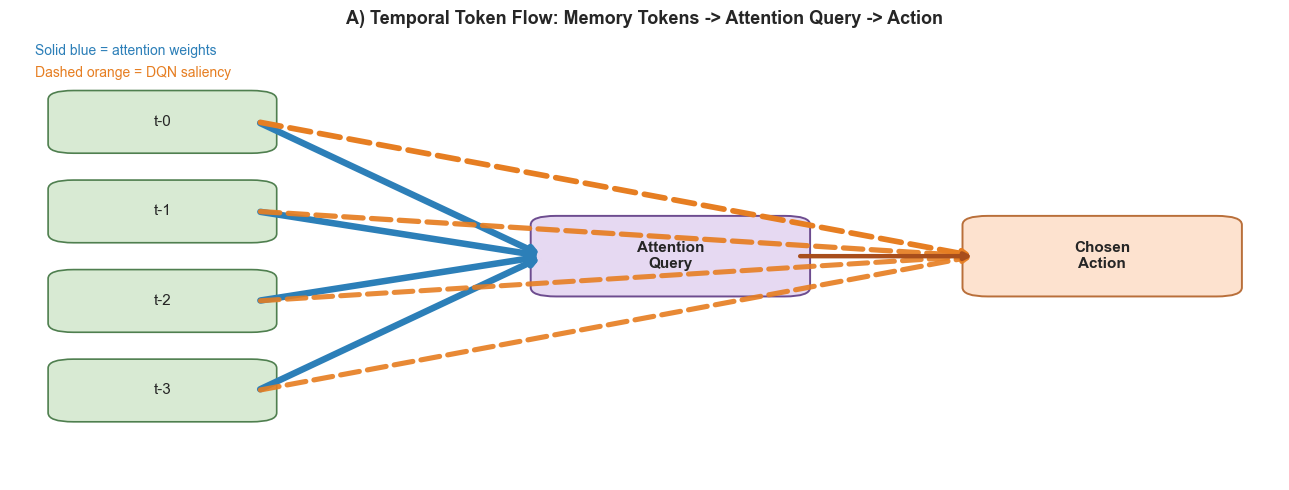

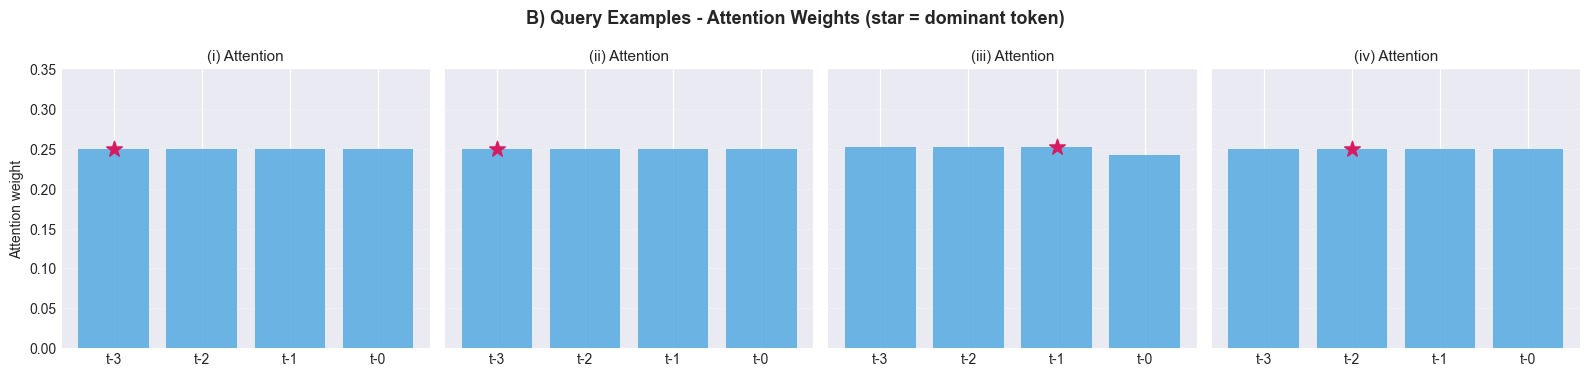

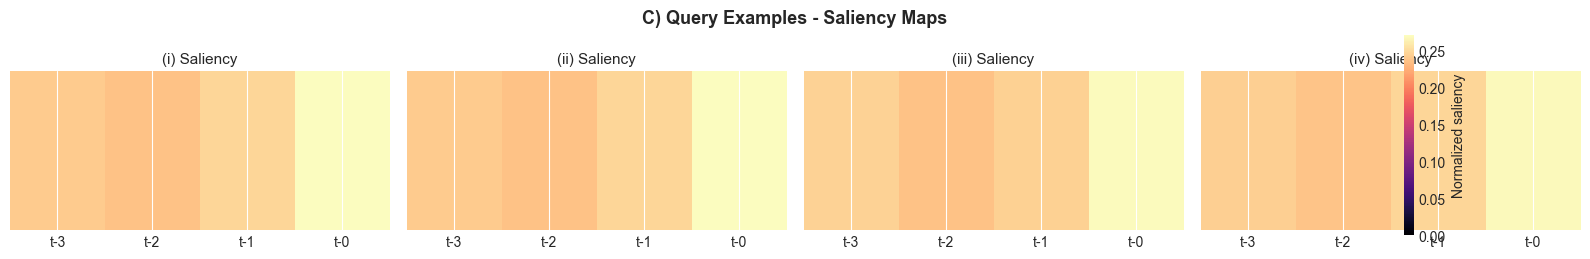

How to read this split view:
1) Figure A shows information pathways (attention path vs saliency path).
2) Figure B shows which token each query attends to most (star marker).
3) Figure C shows where the actual DQN is most sensitive (brighter = stronger saliency).


In [15]:
# Visual explanation panel (split into clearer figures)
print("=== Visual Attention Storyboard (Split View) ===")

import matplotlib.patches as patches

# Ensure arrays are on CPU/NumPy
attn_global = np.array(temporal_attn_mean, dtype=float)
sal_global = np.array(saliency_timestep_mean, dtype=float)

attn_global = attn_global / (attn_global.sum() + 1e-12)
sal_global = sal_global / (sal_global.sum() + 1e-12)

# Build readable token labels (oldest -> newest)
tokens = [f"t-{seq_len-1-i}" for i in range(seq_len)]

# ------------------------------------------------------------------
# Figure 1: Token flow diagram only (attention vs saliency pathways)
# ------------------------------------------------------------------
fig1, ax = plt.subplots(figsize=(13, 5))
ax.set_title("A) Temporal Token Flow: Memory Tokens -> Attention Query -> Action", fontsize=13, fontweight="bold")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

x_mem, x_query, x_action = 0.12, 0.52, 0.86
y_positions = np.linspace(0.20, 0.80, seq_len)

# Memory token boxes
for tok, y in zip(tokens, y_positions):
    box = patches.FancyBboxPatch(
        (x_mem - 0.07, y - 0.05), 0.14, 0.10,
        boxstyle="round,pad=0.02",
        linewidth=1.2,
        facecolor="#d8ead3",
        edgecolor="#4f7f4f",
    )
    ax.add_patch(box)
    ax.text(x_mem, y, tok, ha="center", va="center", fontsize=11)

# Query and action boxes
query_box = patches.FancyBboxPatch(
    (x_query - 0.09, 0.43), 0.18, 0.14,
    boxstyle="round,pad=0.02",
    linewidth=1.4, facecolor="#e6d9f2", edgecolor="#6d4c8f"
)
action_box = patches.FancyBboxPatch(
    (x_action - 0.09, 0.43), 0.18, 0.14,
    boxstyle="round,pad=0.02",
    linewidth=1.4, facecolor="#fde2cf", edgecolor="#b96f3a"
)
ax.add_patch(query_box)
ax.add_patch(action_box)
ax.text(x_query, 0.50, "Attention\nQuery", ha="center", va="center", fontsize=11, fontweight="bold")
ax.text(x_action, 0.50, "Chosen\nAction", ha="center", va="center", fontsize=11, fontweight="bold")

# Attention arrows (blue, solid)
for i, y in enumerate(y_positions):
    w = float(attn_global[i])
    lw = 1.2 + 14.0 * w
    alpha = 0.30 + 0.70 * (w / (attn_global.max() + 1e-12))
    ax.annotate(
        "",
        xy=(x_query - 0.10, 0.50),
        xytext=(x_mem + 0.075, y),
        arrowprops=dict(arrowstyle="-|>", color="#2c7fb8", lw=lw, alpha=alpha),
    )

# Saliency arrows (orange, dashed)
for i, y in enumerate(y_positions):
    w = float(sal_global[i])
    lw = 0.8 + 12.0 * w
    alpha = 0.25 + 0.75 * (w / (sal_global.max() + 1e-12))
    ax.annotate(
        "",
        xy=(x_action - 0.10, 0.50),
        xytext=(x_mem + 0.075, y),
        arrowprops=dict(arrowstyle="->", color="#e67e22", lw=lw, alpha=alpha, linestyle="--"),
    )

# Query-to-action arrow
ax.annotate(
    "",
    xy=(x_action - 0.10, 0.50),
    xytext=(x_query + 0.10, 0.50),
    arrowprops=dict(arrowstyle="-|>", color="#a84e1c", lw=3.2),
)

ax.text(0.02, 0.95, "Solid blue = attention weights", fontsize=10, color="#2c7fb8")
ax.text(0.02, 0.90, "Dashed orange = DQN saliency", fontsize=10, color="#e67e22")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Figure 2: Attention examples only (easy side-by-side comparison)
# ------------------------------------------------------------------
n_examples = min(4, saliency_timestep.shape[0])
attn_per_sample = pool_w_all.mean(dim=1).squeeze(1).detach().cpu().numpy()[:n_examples]

fig2, axes2 = plt.subplots(1, n_examples, figsize=(4 * n_examples, 3.8), sharey=True)
if n_examples == 1:
    axes2 = [axes2]

for j in range(n_examples):
    axj = axes2[j]
    vals = attn_per_sample[j]
    axj.bar(range(seq_len), vals, color="#5dade2", alpha=0.9)
    q_idx = int(np.argmax(vals))
    axj.scatter([q_idx], [vals[q_idx]], s=140, c="#d81b60", marker="*", zorder=5)
    axj.set_xticks(range(seq_len))
    axj.set_xticklabels(tokens)
    axj.set_ylim(0, max(0.35, vals.max() * 1.25))
    axj.set_title(f"({['i','ii','iii','iv'][j]}) Attention", fontsize=11)
    axj.grid(alpha=0.25, axis="y")
    if j == 0:
        axj.set_ylabel("Attention weight")

fig2.suptitle("B) Query Examples - Attention Weights (star = dominant token)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Figure 3: Saliency examples only (matching order with Figure 2)
# ------------------------------------------------------------------
sal_per_sample = saliency_timestep[:n_examples]

fig3, axes3 = plt.subplots(1, n_examples, figsize=(4 * n_examples, 2.6), sharey=True)
if n_examples == 1:
    axes3 = [axes3]

vmax_sal = max(1e-9, sal_per_sample.max())
for j in range(n_examples):
    axj = axes3[j]
    hm = sal_per_sample[j].reshape(1, -1)
    im = axj.imshow(hm, aspect="auto", cmap="magma", vmin=0, vmax=vmax_sal)
    axj.set_xticks(range(seq_len))
    axj.set_xticklabels(tokens)
    axj.set_yticks([])
    axj.set_title(f"({['i','ii','iii','iv'][j]}) Saliency", fontsize=11)

# Single colorbar for consistent reading
cbar = fig3.colorbar(im, ax=axes3, fraction=0.025, pad=0.02)
cbar.set_label("Normalized saliency")

fig3.suptitle("C) Query Examples - Saliency Maps", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("How to read this split view:")
print("1) Figure A shows information pathways (attention path vs saliency path).")
print("2) Figure B shows which token each query attends to most (star marker).")
print("3) Figure C shows where the actual DQN is most sensitive (brighter = stronger saliency).")

## 9.1 Interactive Plotly View (Token Flow + Attention vs Saliency)

In [16]:
# Interactive Plotly view: token flow + temporal comparison
print("=== Interactive Plotly Attention View ===")

import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Safety checks in case prior cells were not run
if 'temporal_attn_mean' not in globals() or 'saliency_timestep_mean' not in globals():
    raise RuntimeError("Please run Cell 19 first to generate attention/saliency arrays.")

seq_len_local = int(seq_len) if 'seq_len' in globals() else len(temporal_attn_mean)
tokens_local = [f"t-{seq_len_local-1-i}" for i in range(seq_len_local)]

attn_global = np.array(temporal_attn_mean, dtype=float)
sal_global = np.array(saliency_timestep_mean, dtype=float)
attn_global = attn_global / (attn_global.sum() + 1e-12)
sal_global = sal_global / (sal_global.sum() + 1e-12)

# --- Figure 1: Sankey token flow ---
node_labels = [f"Memory {t}" for t in tokens_local] + ["Attention Query", "Chosen Action"]
query_idx = len(tokens_local)
action_idx = len(tokens_local) + 1

sources = []
targets = []
values = []
link_colors = []

# Memory -> Query (attention)
for i in range(len(tokens_local)):
    sources.append(i)
    targets.append(query_idx)
    values.append(float(attn_global[i]))
    link_colors.append("rgba(44,127,184,0.70)")

# Memory -> Action (saliency)
for i in range(len(tokens_local)):
    sources.append(i)
    targets.append(action_idx)
    values.append(float(sal_global[i]))
    link_colors.append("rgba(230,126,34,0.55)")

# Query -> Action
sources.append(query_idx)
targets.append(action_idx)
values.append(1.0)
link_colors.append("rgba(168,78,28,0.85)")

fig_flow = go.Figure(
    data=[go.Sankey(
        arrangement="snap",
        node=dict(
            pad=20,
            thickness=22,
            line=dict(color="black", width=0.4),
            label=node_labels,
            color=["#d8ead3"] * len(tokens_local) + ["#e6d9f2", "#fde2cf"],
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=link_colors,
            hovertemplate="%{source.label} -> %{target.label}<br>weight=%{value:.3f}<extra></extra>",
        ),
    )]
)

fig_flow.update_layout(
    title="Interactive Token Flow: Attention (blue) vs Saliency (orange)",
    font=dict(size=12),
    height=520,
    width=1400
)
fig_flow.show()

# --- Figure 2: Temporal comparison + sample heatmap ---
n_examples_local = min(4, saliency_timestep.shape[0])
attn_per_sample_local = pool_w_all.mean(dim=1).squeeze(1).detach().cpu().numpy()[:n_examples_local]
sal_per_sample_local = saliency_timestep[:n_examples_local]

fig_compare = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(
        "Temporal Importance (Global)",
        "Delta from Uniform Baseline",
        "Attention per Query Example",
        "Saliency per Query Example",
    ),
    specs=[[{"type": "xy"}, {"type": "xy"}], [{"type": "heatmap"}, {"type": "heatmap"}]],
    horizontal_spacing=0.12,
    vertical_spacing=0.18,
)

uniform = np.ones_like(attn_global) / len(attn_global)

fig_compare.add_trace(
    go.Scatter(x=tokens_local, y=attn_global, mode="lines+markers", name="Attention", line=dict(color="#2c7fb8", width=3)),
    row=1, col=1
)
fig_compare.add_trace(
    go.Scatter(x=tokens_local, y=sal_global, mode="lines+markers", name="Saliency", line=dict(color="#e67e22", width=3)),
    row=1, col=1
)

fig_compare.add_trace(
    go.Bar(x=tokens_local, y=attn_global - uniform, name="Attention - Uniform", marker_color="#5dade2"),
    row=1, col=2
)
fig_compare.add_trace(
    go.Bar(x=tokens_local, y=sal_global - uniform, name="Saliency - Uniform", marker_color="#f5b041"),
    row=1, col=2
)

fig_compare.add_trace(
    go.Heatmap(
        z=attn_per_sample_local,
        x=tokens_local,
        y=[f"query_{i+1}" for i in range(n_examples_local)],
        colorscale="Blues",
        colorbar=dict(title="attn", x=0.46),
        showscale=True,
        hovertemplate="query=%{y}<br>token=%{x}<br>attn=%{z:.3f}<extra></extra>",
        name="Attention heatmap",
    ),
    row=2, col=1
)

fig_compare.add_trace(
    go.Heatmap(
        z=sal_per_sample_local,
        x=tokens_local,
        y=[f"query_{i+1}" for i in range(n_examples_local)],
        colorscale="Oranges",
        colorbar=dict(title="sal", x=1.02),
        showscale=True,
        hovertemplate="query=%{y}<br>token=%{x}<br>saliency=%{z:.3f}<extra></extra>",
        name="Saliency heatmap",
    ),
    row=2, col=2
)

fig_compare.update_layout(
    height=760,
    width=1400,
    title="Interactive Attention vs Saliency Diagnostics",
    barmode="group",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
)
fig_compare.update_yaxes(title_text="importance", row=1, col=1)
fig_compare.update_yaxes(title_text="delta", row=1, col=2)
fig_compare.show()

print("Why Plotly can be better here:")
print("1) Hover gives exact weights per token instead of eyeballing bar/heatmap colors.")
print("2) Sankey makes the query->action relation visually concrete.")
print("3) Zoom/pan helps compare tiny differences when attention looks nearly uniform.")

=== Interactive Plotly Attention View ===


Why Plotly can be better here:
1) Hover gives exact weights per token instead of eyeballing bar/heatmap colors.
2) Sankey makes the query->action relation visually concrete.
3) Zoom/pan helps compare tiny differences when attention looks nearly uniform.


In [17]:
# Inference utilities and rolling inference demo
print("=== Inference Demo ===")

import plotly.express as px


def infer_action(agent, obs, action_names=None, deterministic=True):
    """Run one-step inference from a single observation window."""
    action, _ = agent.predict(obs, deterministic=deterministic)
    action_id = int(action.item() if isinstance(action, np.ndarray) else action)

    # Also expose Q-values for transparency
    with torch.no_grad():
        q_vals = agent.q_net(torch.tensor(obs, dtype=torch.float32, device=agent.device).unsqueeze(0))
        q_vals = q_vals.detach().cpu().numpy()[0]

    return {
        'action_id': action_id,
        'action_name': action_names[action_id] if action_names is not None else f'Action {action_id}',
        'q_values': q_vals,
        'confidence_gap': float(np.max(q_vals) - np.partition(q_vals, -2)[-2]) if len(q_vals) > 1 else 0.0,
    }


# 1) Single-state inference example
obs0, _ = test_env.reset()
infer0 = infer_action(agent, obs0, action_names=train_env.ACTION_NAMES)

print("Single-step inference:")
print(f"  Predicted action: {infer0['action_id']} ({infer0['action_name']})")
print(f"  Confidence gap (top1-top2 Q): {infer0['confidence_gap']:.6f}")

# Q-values for the single state
q_df = pd.DataFrame({
    'action_id': np.arange(len(infer0['q_values'])),
    'action_name': train_env.ACTION_NAMES,
    'q_value': infer0['q_values']
}).sort_values('q_value', ascending=False)

fig_q = px.bar(
    q_df,
    x='action_name',
    y='q_value',
    title='Inference Q-Values for One State',
    labels={'action_name': 'Action', 'q_value': 'Q-value'}
)
fig_q.update_layout(xaxis_tickangle=-25)
fig_q.show()

# 2) Rolling inference across test period
obs, _ = test_env.reset()
rows = []
max_steps = min(160, len(test_env.features))

for t in range(max_steps):
    inf = infer_action(agent, obs, action_names=train_env.ACTION_NAMES)

    rows.append({
        'step': t,
        'action_id': inf['action_id'],
        'action_name': inf['action_name'],
        'confidence_gap': inf['confidence_gap'],
        'q_max': float(np.max(inf['q_values'])),
    })

    obs, reward, terminated, truncated, _ = test_env.step(inf['action_id'])
    if terminated or truncated:
        break

infer_df = pd.DataFrame(rows)

print(f"\nRolling inference steps: {len(infer_df)}")
print("Top predicted actions:")
print(infer_df['action_name'].value_counts().head(5))

# Interactive timeline of chosen actions
fig_actions = px.scatter(
    infer_df,
    x='step',
    y='action_name',
    color='confidence_gap',
    color_continuous_scale='Viridis',
    title='Rolling Inference: Predicted Actions over Time',
    labels={'step': 'Inference step', 'action_name': 'Predicted action', 'confidence_gap': 'Confidence gap'}
)
fig_actions.show()

# Confidence trend
fig_conf = px.line(
    infer_df,
    x='step',
    y='confidence_gap',
    title='Model Confidence Gap over Time (Top1 - Top2 Q)',
    labels={'step': 'Inference step', 'confidence_gap': 'Confidence gap'}
)
fig_conf.show()

=== Inference Demo ===
Single-step inference:
  Predicted action: 1 (100% SPY)
  Confidence gap (top1-top2 Q): 21.748047



Rolling inference steps: 160
Top predicted actions:
action_name
100% SPY    160
Name: count, dtype: int64


## 9.2 Finance Explainability Dashboard (DQN)

This section links DQN attention/saliency outputs to finance context (returns, actions, and inferred regimes).
Run Section 8 and Section 9 first before executing the dashboard cell.

In [18]:
# 9.2 Finance-native Plotly explainability dashboard (attention + action + regime)
print("=== Explainable RL (Finance View): Attention vs Returns vs Regime ===")

import importlib
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ml.explainability_plotly as xai_plotly
xai_plotly = importlib.reload(xai_plotly)

required_vars = [
    "temporal_attn_mean",
    "saliency_timestep_mean",
    "pool_w_all",
    "saliency_timestep",
    "actions_df",
]
missing = [name for name in required_vars if name not in globals()]
if missing:
    raise RuntimeError(
        "Missing variables for finance dashboard: "
        + ", ".join(missing)
        + ". Run Section 8 and Section 9 first."
    )

# --- Build aligned finance explainability table ---
tokens_local = [f"t-{len(temporal_attn_mean)-1-i}" for i in range(len(temporal_attn_mean))]
attn_per_sample = pool_w_all.mean(dim=1).squeeze(1).detach().cpu().numpy()
sal_per_sample = np.array(saliency_timestep, dtype=float)

n_common = min(len(actions_df), len(attn_per_sample), len(sal_per_sample))
if n_common < 10:
    raise RuntimeError("Not enough aligned samples for finance dashboard. Re-run explainability extraction.")

act_local = actions_df.iloc[:n_common].reset_index(drop=True).copy()
attn_local = attn_per_sample[:n_common]
sal_local = sal_per_sample[:n_common]

act_local["weekly_return"] = act_local["return"].astype(float)
act_local["cum_return"] = (1.0 + act_local["weekly_return"]).cumprod() - 1.0
act_local["attn_recent"] = attn_local[:, -1]
act_local["sal_recent"] = sal_local[:, -1]
act_local["attn_entropy"] = -np.sum(attn_local * np.log(attn_local + 1e-12), axis=1)
act_local["dominant_lag"] = np.argmax(attn_local, axis=1)
act_local["dominant_token"] = [tokens_local[i] for i in act_local["dominant_lag"]]

# Optional regime alignment (from HMM predictions)
if "predicted_regimes" in globals():
    reg = np.asarray(predicted_regimes)
    tail = reg[-n_common:] if len(reg) >= n_common else np.pad(reg, (n_common - len(reg), 0), mode="edge")
    act_local["regime_id"] = tail.astype(int)
    if "hmm" in globals() and hasattr(hmm, "regime_names"):
        act_local["regime_name"] = [hmm.regime_names[i] for i in act_local["regime_id"]]
    else:
        act_local["regime_name"] = [f"Regime_{i}" for i in act_local["regime_id"]]
else:
    act_local["regime_name"] = "Unknown"

# --- Figure 1: Portfolio performance + temporal attention map ---
show_n = min(100, n_common)
view_df = act_local.iloc[:show_n].copy()

fig_fin = make_subplots(
    rows=3,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.08,
    row_heights=[0.34, 0.40, 0.26],
    specs=[[{"type": "xy"}], [{"type": "heatmap"}], [{"type": "xy"}]],
    subplot_titles=(
        "Portfolio Path with Attention-to-Recent Signal",
        "Temporal Attention Heatmap (older to newer state tokens)",
        "Action Timeline + Regime Context",
    ),
)

fig_fin.add_trace(
    go.Scatter(
        x=view_df.index,
        y=view_df["cum_return"],
        mode="lines+markers",
        name="Cumulative return",
        line=dict(color="#115e59", width=3),
        marker=dict(size=5),
        hovertemplate="step=%{x}<br>cum_return=%{y:.2%}<extra></extra>",
    ),
    row=1,
    col=1,
)

fig_fin.add_trace(
    go.Bar(
        x=view_df.index,
        y=view_df["weekly_return"],
        name="Weekly return",
        marker_color="#94a3b8",
        opacity=0.45,
        hovertemplate="step=%{x}<br>weekly_return=%{y:.2%}<extra></extra>",
    ),
    row=1,
    col=1,
)

fig_fin.add_trace(
    go.Scatter(
        x=view_df.index,
        y=view_df["attn_recent"],
        mode="lines",
        name="Attention on most recent token",
        line=dict(color="#b45309", width=2, dash="dot"),
        hovertemplate="step=%{x}<br>attn_recent=%{y:.3f}<extra></extra>",
    ),
    row=1,
    col=1,
)

fig_fin.add_trace(
    go.Heatmap(
        z=attn_local[:show_n].T,
        x=list(range(show_n)),
        y=tokens_local,
        colorscale="YlOrBr",
        name="Attention",
        colorbar=dict(title="attention", x=1.02),
        hovertemplate="step=%{x}<br>token=%{y}<br>attention=%{z:.3f}<extra></extra>",
    ),
    row=2,
    col=1,
)

for action_name in sorted(view_df["action_name"].unique()):
    mask = view_df["action_name"] == action_name
    fig_fin.add_trace(
        go.Scatter(
            x=view_df.index[mask],
            y=view_df["attn_entropy"][mask],
            mode="markers",
            name=f"Action: {action_name}",
            marker=dict(size=8),
            hovertemplate=(
                "step=%{x}<br>action=" + action_name +
                "<br>attn_entropy=%{y:.3f}<extra></extra>"
            ),
            showlegend=False,
        ),
        row=3,
        col=1,
    )

# Regime shading in action panel
for ridx, rname in enumerate(view_df["regime_name"].astype(str).unique()):
    mask = view_df["regime_name"].astype(str) == rname
    if not mask.any():
        continue
    xvals = view_df.index[mask]
    fig_fin.add_trace(
        go.Scatter(
            x=xvals,
            y=[-0.02] * len(xvals),
            mode="markers",
            marker=dict(symbol="square", size=7),
            name=f"Regime: {rname}",
            hovertemplate="step=%{x}<br>regime=" + rname + "<extra></extra>",
            showlegend=(ridx < 4),
        ),
        row=3,
        col=1,
    )

fig_fin.update_layout(
    title="Finance XAI Dashboard: Where the RL policy attends when allocating portfolio",
    height=980,
    width=1400,
    barmode="overlay",
    legend=dict(orientation="h", y=1.03, x=0),
)
fig_fin.update_yaxes(title_text="return", tickformat=".1%", row=1, col=1)
fig_fin.update_yaxes(title_text="token", row=2, col=1)
fig_fin.update_yaxes(title_text="attention entropy", row=3, col=1)
fig_fin.update_xaxes(title_text="test step", row=3, col=1)
fig_fin.show()

# --- Figure 2: Regime vs action preference heatmap ---
pivot = (
    act_local.groupby(["regime_name", "action_name"])  # type: ignore[arg-type]
    .size()
    .reset_index(name="count")
)

regimes = sorted(pivot["regime_name"].unique())
actions = sorted(pivot["action_name"].unique())
mat = np.zeros((len(regimes), len(actions)), dtype=float)

for _, row in pivot.iterrows():
    i = regimes.index(row["regime_name"])
    j = actions.index(row["action_name"])
    mat[i, j] = row["count"]

row_sums = mat.sum(axis=1, keepdims=True) + 1e-12
mat_pct = mat / row_sums

fig_policy = go.Figure(
    data=[
        go.Heatmap(
            z=mat_pct,
            x=actions,
            y=regimes,
            colorscale="Teal",
            hovertemplate="regime=%{y}<br>action=%{x}<br>prob=%{z:.2%}<extra></extra>",
            colorbar=dict(title="P(action|regime)"),
        )
    ]
)
fig_policy.update_layout(
    title="Policy Behavior by Market Regime (Empirical action probabilities)",
    height=420,
    xaxis_title="action",
    yaxis_title="regime",
)
fig_policy.show()

# --- Figure 3: Named finance attention heads (tab-style selector) ---
action_mix = view_df["action_name"].value_counts(normalize=True)

fig_heads = xai_plotly.create_finance_attention_heads_figure(
    sample_attention=attn_local[:show_n],
    sample_saliency=sal_local[:show_n],
    weekly_returns=view_df["weekly_return"].values,
    token_labels=tokens_local,
    action_labels=action_mix.index.tolist(),
    action_distribution=action_mix.values,
    title="Finance Attention Head Explorer",
)
fig_heads.show()

print("Finance explainability view ready:")
print("1) Links attention weights to real portfolio returns over time.")
print("2) Shows which lookback token the policy emphasizes at each step.")
print("3) Summarizes action preferences by inferred market regime.")
print("4) Adds tab-style named heads: Trend-following, Risk-aware, Local context.")

=== Explainable RL (Finance View): Attention vs Returns vs Regime ===


Finance explainability view ready:
1) Links attention weights to real portfolio returns over time.
2) Shows which lookback token the policy emphasizes at each step.
3) Summarizes action preferences by inferred market regime.
4) Adds tab-style named heads: Trend-following, Risk-aware, Local context.


## 9.3 PPO + Attention Explainability (Surrogate + Saliency)

In [19]:
# PPO-specific attention-style explainability via surrogate attention + policy saliency
print("=== PPO Attention + Saliency (Finance) ===")

import torch.nn as nn
import torch.optim as optim
import plotly.graph_objects as go
from plotly.subplots import make_subplots

if 'ppo_agent' not in globals():
    raise RuntimeError("Please run the PPO training cell in Section 6.2 first.")

# Collect PPO rollout states from test period
obs, _ = test_env.reset()
ppo_states = []
n_collect_ppo = 220

for _ in range(n_collect_ppo):
    ppo_states.append(obs.copy())
    act, _ = ppo_agent.predict(obs, deterministic=True)
    act_id = int(act.item() if isinstance(act, np.ndarray) else act)
    obs, _, terminated, truncated, _ = test_env.step(act_id)
    if terminated or truncated:
        obs, _ = test_env.reset()

X_ppo_np = np.array(ppo_states, dtype=np.float32)  # [N, T, F]
X_ppo = torch.tensor(X_ppo_np, dtype=torch.float32, device=ppo_agent.device)

# Teacher targets from PPO policy distribution
with torch.no_grad():
    teacher_dist = ppo_agent.policy.get_distribution(X_ppo)
    teacher_probs = teacher_dist.distribution.probs.detach()  # [N, n_actions]


class AttentionPolicySurrogate(nn.Module):
    def __init__(self, in_dim, n_actions, d_model=64, n_heads=4):
        super().__init__()
        self.proj = nn.Linear(in_dim, d_model)
        self.attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.query = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        self.head = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Linear(64, n_actions),
        )

    def forward(self, x):
        h = torch.relu(self.proj(x))
        h_attn, attn_w = self.attn(h, h, h, need_weights=True, average_attn_weights=False)
        q = self.query.expand(h_attn.size(0), -1, -1)
        pooled, pool_w = self.attn(q, h_attn, h_attn, need_weights=True, average_attn_weights=False)
        logits = self.head(pooled.squeeze(1))
        return logits, attn_w, pool_w


n_actions_ppo = train_env.action_space.n
ppo_surrogate = AttentionPolicySurrogate(
    in_dim=X_ppo.shape[-1],
    n_actions=n_actions_ppo,
    d_model=64,
    n_heads=4,
).to(ppo_agent.device)

optimizer = optim.Adam(ppo_surrogate.parameters(), lr=1e-3)
loss_fn = nn.KLDivLoss(reduction='batchmean')

batch_size = 64
epochs = 25
num_samples = X_ppo.size(0)

for epoch in range(epochs):
    perm = torch.randperm(num_samples, device=ppo_agent.device)
    epoch_loss = 0.0
    for i in range(0, num_samples, batch_size):
        idx = perm[i:i + batch_size]
        xb = X_ppo[idx]
        yb = teacher_probs[idx]

        logits, _, _ = ppo_surrogate(xb)
        log_probs = torch.log_softmax(logits, dim=1)
        loss = loss_fn(log_probs, yb)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        epoch_loss += float(loss.item()) * xb.size(0)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs} - KL: {epoch_loss / num_samples:.6f}")

# Extract attention weights
with torch.no_grad():
    _, _, ppo_pool_w = ppo_surrogate(X_ppo)

ppo_temporal_attn = ppo_pool_w.mean(dim=(0, 1, 2)).detach().cpu().numpy()
ppo_temporal_attn = ppo_temporal_attn / (ppo_temporal_attn.sum() + 1e-12)
ppo_attn_per_sample = ppo_pool_w.mean(dim=1).squeeze(1).detach().cpu().numpy()

# Compute PPO policy saliency wrt chosen action probability
n_sal = min(120, X_ppo_np.shape[0])
ppo_saliency_timestep = []

for i in range(n_sal):
    obs_leaf = torch.tensor(X_ppo_np[i], dtype=torch.float32, device=ppo_agent.device, requires_grad=True)
    dist = ppo_agent.policy.get_distribution(obs_leaf.unsqueeze(0))
    probs = dist.distribution.probs[0]
    chosen = int(torch.argmax(probs).item())
    score = torch.log(probs[chosen] + 1e-12)

    ppo_agent.policy.zero_grad(set_to_none=True)
    score.backward()

    grad_abs = obs_leaf.grad.detach().abs().cpu().numpy()  # [T, F]
    sal_t = grad_abs.sum(axis=1)
    sal_t = sal_t / (sal_t.sum() + 1e-12)
    ppo_saliency_timestep.append(sal_t)

ppo_saliency_timestep = np.array(ppo_saliency_timestep)
ppo_saliency_mean = ppo_saliency_timestep.mean(axis=0)

token_labels = [f"t-{len(ppo_temporal_attn)-1-i}" for i in range(len(ppo_temporal_attn))]

# Align returns for finance overlay
if 'ppo_prob_df' in globals() and 'actions_df' in globals():
    n_show = min(100, len(ppo_attn_per_sample), len(actions_df), len(ppo_prob_df))
    ret_series = actions_df['return'].iloc[:n_show].astype(float).values
else:
    n_show = min(100, len(ppo_attn_per_sample))
    ret_series = np.zeros(n_show, dtype=float)

fig = make_subplots(
    rows=3,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.08,
    row_heights=[0.32, 0.36, 0.32],
    subplot_titles=(
        "PPO Temporal Importance: Surrogate Attention vs Policy Saliency",
        "PPO Attention Heatmap by Step",
        "Weekly Return vs PPO Focus on Recent Token",
    ),
)

fig.add_trace(
    go.Scatter(
        x=token_labels,
        y=ppo_temporal_attn,
        mode='lines+markers',
        name='PPO attention',
        line=dict(color='#0f766e', width=3),
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=token_labels,
        y=ppo_saliency_mean,
        mode='lines+markers',
        name='PPO saliency',
        line=dict(color='#b45309', width=3, dash='dot'),
    ),
    row=1,
    col=1,
)

fig.add_trace(
    go.Heatmap(
        z=ppo_attn_per_sample[:n_show].T,
        x=list(range(n_show)),
        y=token_labels,
        colorscale='Teal',
        colorbar=dict(title='attn', x=1.02),
        hovertemplate='step=%{x}<br>token=%{y}<br>attn=%{z:.3f}<extra></extra>',
        name='PPO attention heatmap',
    ),
    row=2,
    col=1,
)

fig.add_trace(
    go.Bar(
        x=list(range(n_show)),
        y=ret_series,
        name='Weekly return',
        marker_color='#94a3b8',
        opacity=0.5,
    ),
    row=3,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=list(range(n_show)),
        y=ppo_attn_per_sample[:n_show, -1],
        mode='lines',
        name='Attention on most recent token',
        line=dict(color='#7c2d12', width=2),
    ),
    row=3,
    col=1,
)

fig.update_layout(
    height=980,
    width=1400,
    title='PPO + Attention Explainability Dashboard',
    legend=dict(orientation='h', y=1.03, x=0),
)
fig.update_yaxes(title_text='importance', row=1, col=1)
fig.update_yaxes(title_text='token', row=2, col=1)
fig.update_yaxes(title_text='return / focus', row=3, col=1)
fig.update_xaxes(title_text='test step', row=3, col=1)
fig.show()

print("PPO attention diagnostics ready.")
print("Run order: Section 6.2 (PPO training) -> this section.")

=== PPO Attention + Saliency (Finance) ===
Epoch 5/25 - KL: 0.000142
Epoch 10/25 - KL: 0.000066
Epoch 15/25 - KL: 0.000053
Epoch 20/25 - KL: 0.000045
Epoch 25/25 - KL: 0.000041


PPO attention diagnostics ready.
Run order: Section 6.2 (PPO training) -> this section.


## 10. Compare Against Baseline (Without Regimes)

In [ ]:
# Create baseline environments without regime information
train_baseline_features = train_features_normalized.copy()
train_baseline_regimes = np.zeros((len(train_baseline_features), 4))

val_baseline_features = val_features_normalized.copy()
val_baseline_regimes = np.zeros((len(val_baseline_features), 4))

test_baseline_features = test_features_normalized.copy()
test_baseline_regimes = np.zeros((len(test_baseline_features), 4))

train_baseline_env = WeeklyPortfolioEnv(
    features=train_baseline_features,
    regime_posteriors=train_baseline_regimes,
    asset_returns=portfolio_returns.loc[train_baseline_features.index],
    seq_len=4
)

test_baseline_env = WeeklyPortfolioEnv(
    features=test_baseline_features,
    regime_posteriors=test_baseline_regimes,
    asset_returns=portfolio_returns.loc[test_baseline_features.index],
    seq_len=4
)

# Train baseline agent (no regime info)
print("=== Training Baseline Agent (No Regime Info) ===")

baseline_agent = DQN(
    'MlpPolicy',
    train_baseline_env,
    learning_rate=1e-4,
    buffer_size=10000,
    learning_starts=1000,
    batch_size=32,
    gamma=0.99,
    train_freq=1,
    target_update_interval=1000,
    exploration_fraction=0.15,
    exploration_initial_eps=1.0,
    exploration_final_eps=0.05,
    device=device,
    verbose=0
)

baseline_agent.learn(total_timesteps=50000, progress_bar=True)

# Evaluate both agents
baseline_test_eval = evaluate_episode(baseline_agent, test_baseline_env, deterministic=True)

print("\n=== Performance Comparison ===")
print(f"\nRegime-Aware Agent (Test):")
print(f"  Reward: {test_eval['reward']:.4f}")
print(f"  Length: {test_eval['length']}")
print(f"  Avg Reward/Step: {test_eval['avg_reward']:.4f}")
print(f"  Sharpe Ratio: {test_eval.get('sharpe_ratio', 0):.4f}")

print(f"\nBaseline Agent (Test, No Regimes):")
print(f"  Reward: {baseline_test_eval['reward']:.4f}")
print(f"  Length: {baseline_test_eval['length']}")
print(f"  Avg Reward/Step: {baseline_test_eval['avg_reward']:.4f}")
print(f"  Sharpe Ratio: {baseline_test_eval.get('sharpe_ratio', 0):.4f}")

improvement = (test_eval['reward'] - baseline_test_eval['reward']) / (abs(baseline_test_eval['reward']) + 1e-8)
print(f"\nImprovement (Regime-Aware): {improvement*100:.2f}%")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reward comparison
agents = ['Regime-Aware', 'Baseline (No Regimes)']
rewards = [test_eval['reward'], baseline_test_eval['reward']]
colors = ['green', 'orange']
bars = axes[0].bar(agents, rewards, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[0].set_title('Test Period Rewards Comparison', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Total Reward')
axes[0].axhline(0, color='r', linestyle='--', alpha=0.3)
for bar, reward in zip(bars, rewards):
    axes[0].text(bar.get_x() + bar.get_width()/2, reward, f'{reward:.4f}', 
                ha='center', va='bottom' if reward > 0 else 'top', fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')

# Sharpe ratio comparison
sharpe_aware = test_eval.get('sharpe_ratio', 0)
sharpe_baseline = baseline_test_eval.get('sharpe_ratio', 0)
sharpe_vals = [sharpe_aware, sharpe_baseline]
bars = axes[1].bar(agents, sharpe_vals, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[1].set_title('Sharpe Ratio Comparison', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Sharpe Ratio')
for bar, sharpe in zip(bars, sharpe_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, sharpe, f'{sharpe:.4f}', 
                ha='center', va='bottom' if sharpe > 0 else 'top', fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Output()

=== Training Baseline Agent (No Regime Info) ===


## 11. Ablation Study - Impact of Attention Heads

In [ ]:
# print("=== Ablation Study: Learning Rate & Buffer Size ===")

# # Test different hyperparameter combinations
# hyperparams = [
#     {'learning_rate': 1e-4, 'buffer_size': 5000, 'name': 'LR=1e-4, Buffer=5k'},
#     {'learning_rate': 1e-4, 'buffer_size': 10000, 'name': 'LR=1e-4, Buffer=10k'},
#     {'learning_rate': 1e-4, 'buffer_size': 20000, 'name': 'LR=1e-4, Buffer=20k'},
#     {'learning_rate': 5e-5, 'buffer_size': 10000, 'name': 'LR=5e-5, Buffer=10k'},
# ]

# ablation_results = {}

# for config in tqdm(hyperparams):
#     print(f"\nTesting {config['name']}...")
    
#     np.random.seed(42)
    
#     test_agent = DQN(
#         'MlpPolicy',
#         train_env,
#         learning_rate=config['learning_rate'],
#         buffer_size=config['buffer_size'],
#         learning_starts=1000,
#         batch_size=32,
#         gamma=0.99,
#         train_freq=1,
#         target_update_interval=1000,
#         device=device,
#         verbose=0
#     )
    
#     test_agent.learn(total_timesteps=30000, progress_bar=False)
    
#     eval_result = evaluate_episode(test_agent, val_env, deterministic=True)
#     ablation_results[config['name']] = eval_result
#     print(f"  Reward: {eval_result['reward']:.4f}, Avg: {eval_result['avg_reward']:.4f}")

# # Visualize ablation results
# config_names = list(ablation_results.keys())
# ablation_rewards = [ablation_results[k]['reward'] for k in config_names]
# ablation_avg = [ablation_results[k]['avg_reward'] for k in config_names]

# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# axes[0].barh(config_names, ablation_rewards, color='steelblue', alpha=0.7, edgecolor='black')
# axes[0].set_title('Total Episode Reward by Hyperparameter Config', fontsize=12, fontweight='bold')
# axes[0].set_xlabel('Total Reward')
# axes[0].grid(alpha=0.3, axis='x')
# for i, (name, reward) in enumerate(zip(config_names, ablation_rewards)):
#     axes[0].text(reward, i, f' {reward:.4f}', va='center')

# axes[1].barh(config_names, ablation_avg, color='orange', alpha=0.7, edgecolor='black')
# axes[1].set_title('Average Reward per Step by Config', fontsize=12, fontweight='bold')
# axes[1].set_xlabel('Average Reward/Step')
# axes[1].grid(alpha=0.3, axis='x')
# for i, (name, avg) in enumerate(zip(config_names, ablation_avg)):
#     axes[1].text(avg, i, f' {avg:.4f}', va='center')

# plt.tight_layout()
# plt.show()

# print("\nAblation Summary:")
# for config_name in config_names:
#     result = ablation_results[config_name]
#     print(f"  {config_name}:")
#     print(f"    Reward={result['reward']:.4f}, Avg/Step={result['avg_reward']:.4f}")